In [ ]:
import pandas as pd
import numpy as np

In [ ]:
pd.set_option('display.max_columns', None)

# Assembling a dataset with transactions in 2017

In [ ]:
df_01_02_17 = pd.read_csv('data/transactions/!01_02_17_VSE.csv', encoding='cp1251', sep=';', low_memory=False)
df_01_02_17["ДатаДоставки"] = pd.to_datetime(df_01_02_17["ДатаДоставки"], dayfirst=True, errors="coerce")
df_01_02_17['ДатаДоставки'].dt.to_period('M').value_counts().sort_index()

In [ ]:
!unar -o data/transactions data/transactions/!03_04_17_VSE.rar

In [ ]:
df_03_04_17 = pd.read_csv('data/transactions/!03&04_17_VSE.csv', encoding='cp1251', sep=';', low_memory=False)
df_03_04_17["ДатаДоставки"] = pd.to_datetime(df_03_04_17["ДатаДоставки"], dayfirst=True, errors="coerce")
df_03_04_17['ДатаДоставки'].dt.to_period('M').value_counts().sort_index()

In [ ]:
!unar -o data/transactions data/transactions/!05_06_17_VSE.rar

In [ ]:
df_05_06_17 = pd.read_csv('data/transactions/!05&06_17_VSE.csv', encoding='cp1251', sep=';', low_memory=False)
df_05_06_17["ДатаДоставки"] = pd.to_datetime(df_05_06_17["ДатаДоставки"], dayfirst=True, errors="coerce")
df_05_06_17['ДатаДоставки'].dt.to_period('M').value_counts().sort_index()

In [ ]:
!unar -o data/transactions data/transactions/!07_08_17_VSE.rar

In [ ]:
df_07_08_17 = pd.read_csv('data/transactions/!07&08_17_VSE.csv', encoding='cp1251', sep=';', low_memory=False)
df_07_08_17["ДатаДоставки"] = pd.to_datetime(df_07_08_17["ДатаДоставки"], dayfirst=True, errors="coerce")
df_07_08_17['ДатаДоставки'].dt.to_period('M').value_counts().sort_index()

In [ ]:
df_09_10_17 = pd.read_csv('data/transactions/!09_10_17_VSE.csv', encoding='cp1251', sep=';', low_memory=False)
df_09_10_17["ДатаДоставки"] = pd.to_datetime(df_09_10_17["ДатаДоставки"], dayfirst=True, errors="coerce")
df_09_10_17['ДатаДоставки'].dt.to_period('M').value_counts().sort_index()

In [ ]:
df_11_17 = pd.read_csv('data/transactions/!11_17_VSE.csv', encoding='cp1251', sep=';', low_memory=False)
df_11_17["ДатаДоставки"] = pd.to_datetime(df_11_17["ДатаДоставки"], dayfirst=True, errors="coerce")
df_11_17['ДатаДоставки'].dt.to_period('M').value_counts().sort_index()

In [ ]:
df_11_17.isna().sum()

In [ ]:
df_12_17 = pd.read_csv(
    'data/transactions/!12_17_VSE.csv',
    encoding='cp1251',
    sep='\t',
    low_memory=False
)

df_12_17

In [ ]:
df_12_17.shape

In [ ]:
df_12_17["ДатаДоставки"] = pd.to_datetime(df_12_17["ДатаДоставки"], dayfirst=True, errors="coerce")
df_12_17['ДатаДоставки'].dt.to_period('M').value_counts().sort_index()

In [ ]:
df_01_02_18 = pd.read_csv('data/transactions/!01_02-18_VSE.csv', encoding='cp1251', sep=';', low_memory=False)
df_01_02_18["ДатаДоставки"] = pd.to_datetime(df_01_02_18["ДатаДоставки"], dayfirst=True, errors="coerce")
df_01_02_18['ДатаДоставки'].dt.to_period('M').value_counts().sort_index()

In [ ]:
import re
from pathlib import Path
import pandas as pd

def parse_months_year_from_name(filename: str):
    """
    Примеры:
      !01_02_17_VSE.csv
      !03&04_17_VSE.csv
      !01_02-18_VSE.csv
      !11_17_VSE.csv
    Возвращает (year:int, months:list[int])
    """
    name = Path(filename).name

    # Жёсткий разбор: после ! идёт M1, опционально [_&]M2, затем [_-]YY, затем _VSE
    m = re.search(r'!(\d{2})(?:[_&](\d{2}))?[_-](\d{2})_VSE', name)
    if not m:
        raise ValueError(f"Не распознала формат имени: {name}")

    m1 = int(m.group(1))
    m2 = m.group(2)
    yy = int(m.group(3))

    months = [m1] + ([int(m2)] if m2 is not None else [])
    if any((mm < 1 or mm > 12) for mm in months):
        raise ValueError(f"Некорректный месяц в имени {name}: {months}")

    year = 2000 + yy
    return year, months


def load_and_filter(file_path: str, date_col="ДатаДоставки"):
    df = pd.read_csv(file_path, encoding="cp1251", sep=";", low_memory=False)
    df[date_col] = pd.to_datetime(df[date_col], dayfirst=True, errors="coerce")

    year, months = parse_months_year_from_name(file_path)
    allowed = {pd.Period(f"{year}-{m:02d}", freq="M") for m in months}

    per = df[date_col].dt.to_period("M")
    out = df.loc[per.isin(allowed)].copy()
    out["_source_file"] = Path(file_path).name
    return out


def build_dataset(file_paths, out_parquet=None):
    parts = []
    for p in file_paths:
        parts.append(load_and_filter(p))

    big = pd.concat(parts, ignore_index=True)

    # Контроль: покажи, какие месяцы реально попали
    print(big["ДатаДоставки"].dt.to_period("M").value_counts().sort_index())

    if out_parquet:
        big.to_parquet(out_parquet, index=False)

    return big

In [ ]:
for f in files_2017:
    y, ms = parse_months_year_from_name(f)
    print(Path(f).name, "->", y, ms)

In [ ]:
files_2017 = [
    "data/transactions/!01_02_17_VSE.csv",
    "data/transactions/!03&04_17_VSE.csv",
    "data/transactions/!05&06_17_VSE.csv",
    "data/transactions/!07&08_17_VSE.csv",
    "data/transactions/!09_10_17_VSE.csv",
    "data/transactions/!11_17_VSE.csv",
]

df_2017 = build_dataset(files_2017, out_parquet="data/transactions/transactions_2017.parquet")

# Read dataset

In [ ]:
df = pd.read_parquet("data/transactions/transactions_2017_clean.parquet")

In [ ]:
df.head()

In [ ]:
# оставила датасет только с доставленными заказами
filt_delivered = (
    (df['Отменено'] == 'Нет') &
    (df['Статус'] == 'Доставлен') &
    (df['КоличествоПроданоКлиенту'] > 0)
)
df_delivered = df.loc[filt_delivered].copy()
df_delivered = df_delivered.sort_values(['Телефон_new', 'Дата']).copy()

In [ ]:
df_delivered.head()

# Group by clients and quarter

In [ ]:
client_df = df_delivered.groupby(['Телефон_new', 'quarter']).agg(
    delivered_orders=('НомерЗаказаНаСайте', 'nunique'),
    items=('КоличествоПроданоКлиенту', 'sum'),
    revenue=('СуммаСтроки', 'sum'),
    margin=('Маржа', 'sum'),
    first_purchase=('Дата', 'min'),                                                            
    last_purchase=('Дата', 'max'),                                         
).reset_index()
client_df['avg_order_value'] = client_df['revenue'] / client_df['delivered_orders']
client_df = client_df.sort_values(by='revenue', ascending=False)

In [ ]:
client_df

In [ ]:
# 1) размер заказа внутри квартала
order_sizes_q = (
    df_delivered
    .groupby(['Телефон_new', 'quarter', 'НомерЗаказаНаСайте'])['КоличествоПроданоКлиенту']
    .sum()
    .reset_index(name='order_size')
)

# 2) самый частый размер заказа внутри квартала
most_freq_order_size_q = (
    order_sizes_q
    .groupby(['Телефон_new', 'quarter'])['order_size']
    .agg(lambda x: x.mode().iat[0] if not x.mode().empty else None)
    .reset_index(name='most_freq_order_size')
)

In [ ]:
import pandas as pd

# --- 0) приведение типов (критично для merge_asof) ---
df_delivered = df_delivered.copy()
client_df = client_df.copy()

df_delivered['Дата'] = pd.to_datetime(df_delivered['Дата'])
# если quarter у тебя строка вида "2017Q4", раскомментируй следующую строку:
# client_df['quarter'] = pd.PeriodIndex(client_df['quarter'], freq='Q')

# --- 1) первая покупка "за всю историю" (в пределах твоих данных) ---
first_purchase_overall = (
    df_delivered.groupby('Телефон_new', as_index=False)['Дата']
    .min()
    .rename(columns={'Дата': 'first_purchase_overall'})
)

# --- 2) панель (клиент × квартал) + конец квартала ---
state_q = (
    client_df[['Телефон_new', 'quarter']]
    .drop_duplicates()
    .copy()
)

state_q['quarter_end'] = pd.to_datetime(state_q['quarter'].dt.end_time)

# --- 3) покупки (для asof): только нужные колонки, сортировка ОБЯЗАТЕЛЬНА ---
purch = (
    df_delivered[['Телефон_new', 'Дата']]
    .dropna()
    .sort_values(['Дата', 'Телефон_new'])      # важно: время первым
    .reset_index(drop=True)
)

# --- 4) merge_asof: последняя покупка ДО конца квартала (вариант A) ---
state_q = (
    state_q
    .sort_values(['quarter_end', 'Телефон_new'])  # важно: время первым
    .reset_index(drop=True)
)

state_q = pd.merge_asof(
    state_q,
    purch,
    left_on='quarter_end',
    right_on='Дата',
    by='Телефон_new',
    direction='backward',
    allow_exact_matches=True
).rename(columns={'Дата': 'last_purchase_before_q_end'})

# --- 5) tenure и recency на конец квартала ---
state_q = state_q.merge(first_purchase_overall, on='Телефон_new', how='left')

state_q['days_since_first_purchase'] = (
    state_q['quarter_end'] - state_q['first_purchase_overall']
).dt.days

state_q['recency_days'] = (
    state_q['quarter_end'] - state_q['last_purchase_before_q_end']
).dt.days

# убираем кварталы ДО первой покупки (иначе recency будет NaN и это НЕ "Lost")
state_q = state_q[state_q['days_since_first_purchase'] >= 0].copy()

# --- 6) мёрдж в витрину клиент-квартал ---
client_df = (
    client_df
    .merge(
        state_q[['Телефон_new', 'quarter', 'recency_days', 'days_since_first_purchase']],
        on=['Телефон_new', 'quarter'],
        how='left'
    )
    .merge(
        most_freq_order_size_q,  # должно быть client×quarter
        on=['Телефон_new', 'quarter'],
        how='left'
    )
)

# (опционально) быстрая диагностика после пересчёта
# print(client_df.groupby('quarter')['recency_days'].apply(lambda s: s.isna().mean()))

In [ ]:
client_df.head()

In [ ]:
client_df['recency_days'].max()

### Доли категорий по кол-ву товаров

In [ ]:
# 1) Количество проданных единиц по клиенту, кварталу и категории
category_share_q = (
    df_delivered.groupby(['Телефон_new', 'quarter', 'Группа2'])['КоличествоПроданоКлиенту']
    .sum()
    .reset_index()
    .rename(columns={'КоличествоПроданоКлиенту': 'num_items_per_categ'})
)

# 2) Общее количество проданных единиц по клиенту и кварталу
total_items_q = (
    category_share_q.groupby(['Телефон_new', 'quarter'])['num_items_per_categ']
    .sum()
    .reset_index()
    .rename(columns={'num_items_per_categ': 'total_num_items'})
)

# 3) Доля категории по количеству внутри квартала
category_share_q = category_share_q.merge(total_items_q, on=['Телефон_new', 'quarter'], how='left')
category_share_q['num_items_share'] = (
    category_share_q['num_items_per_categ'] / category_share_q['total_num_items']
)

# 4) Wide-формат: одна строка = клиент-квартал, колонки = категории (Группа2)
category_pivot_q = (
    category_share_q.pivot_table(
        index=['Телефон_new', 'quarter'],
        columns='Группа2',
        values='num_items_share',
        fill_value=0
    )
    .reset_index()
)

# (необязательно, но полезно) сделать “безопасные” имена колонок
# category_pivot_q.columns = [str(c).strip().replace(' ', '_') if c not in ['Телефон_new','quarter'] else c
#                             for c in category_pivot_q.columns]

# 5) Merge с витриной клиент-квартал
client_df = client_df.merge(category_pivot_q, on=['Телефон_new', 'quarter'], how='left')

In [ ]:
client_df.head()

### Доли регионов по кол-ву товара

In [ ]:
# убедись, что quarter уже есть
df_delivered['Дата'] = pd.to_datetime(df_delivered['Дата'])
df_delivered['quarter'] = df_delivered['Дата'].dt.to_period('Q')

# 1) Количество проданных единиц по клиенту, кварталу и региону
region_share_q = (
    df_delivered.groupby(['Телефон_new', 'quarter', 'Регион'])['КоличествоПроданоКлиенту']
    .sum()
    .reset_index()
    .rename(columns={'КоличествоПроданоКлиенту': 'num_items_per_region'})
)

# 2) Общее количество проданных единиц по клиенту и кварталу
total_items_region_q = (
    region_share_q.groupby(['Телефон_new', 'quarter'])['num_items_per_region']
    .sum()
    .reset_index()
    .rename(columns={'num_items_per_region': 'total_num_items'})
)

# 3) Доля региона по количеству внутри квартала
region_share_q = region_share_q.merge(total_items_region_q, on=['Телефон_new', 'quarter'], how='left')
region_share_q['region_items_share'] = (
    region_share_q['num_items_per_region'] / region_share_q['total_num_items']
)

# 4) Wide-формат: одна строка = клиент-квартал, колонки = регионы
region_pivot_q = (
    region_share_q.pivot_table(
        index=['Телефон_new', 'quarter'],
        columns='Регион',
        values='region_items_share',
        fill_value=0
    )
    .reset_index()
)

# 5) Merge с витриной (оставляю имя client_df как ты просил)
client_df = client_df.merge(region_pivot_q, on=['Телефон_new', 'quarter'], how='left')

In [ ]:
client_df.head()

### Доли МетодДоставки по кол-ву заказов

In [ ]:
df_delivered['МетодДоставки'].value_counts()

In [ ]:
# 1) Кол-во уникальных заказов по клиенту, кварталу и методу доставки
deliv_orders_q = (
    df_delivered
    .groupby(['Телефон_new', 'quarter', 'МетодДоставки'])['НомерЗаказаНаСайте']
    .nunique()
    .reset_index(name='orders_per_method')
)

# 2) Подтягиваем delivered_orders из витрины (теперь по клиенту+кварталу)
deliv_orders_q = deliv_orders_q.merge(
    client_df[['Телефон_new', 'quarter', 'delivered_orders']],
    on=['Телефон_new', 'quarter'],
    how='left'
)

# 3) Доля заказов по каждому методу доставки внутри квартала
deliv_orders_q['delivery_order_share'] = (
    deliv_orders_q['orders_per_method'] / deliv_orders_q['delivered_orders']
)

# 4) wide-формат: по столбцу на каждый метод доставки
delivery_pivot_q = (
    deliv_orders_q
    .pivot_table(
        index=['Телефон_new', 'quarter'],
        columns='МетодДоставки',
        values='delivery_order_share',
        fill_value=0
    )
    .add_prefix('delivery_')
    .reset_index()
)

In [ ]:
client_df = client_df.merge(delivery_pivot_q, on=['Телефон_new','quarter'], how='left')

### Доли для ФормаОплаты по кол-ву заказов

In [ ]:
pay_orders_q = (
    df_delivered
    .groupby(['Телефон_new', 'quarter', 'ФормаОплаты'])['НомерЗаказаНаСайте']
    .nunique()
    .reset_index(name='orders_per_method')
)

pay_orders_q = pay_orders_q.merge(
    client_df[['Телефон_new', 'quarter', 'delivered_orders']],
    on=['Телефон_new', 'quarter'],
    how='left'
)

pay_orders_q['payment_order_share'] = (
    pay_orders_q['orders_per_method'] / pay_orders_q['delivered_orders']
)

payment_pivot_q = (
    pay_orders_q
    .pivot_table(
        index=['Телефон_new', 'quarter'],
        columns='ФормаОплаты',
        values='payment_order_share',
        fill_value=0
    )
    .add_prefix('payment_')
    .reset_index()
)

In [ ]:
client_df = client_df.merge(payment_pivot_q, on=['Телефон_new','quarter'], how='left')

In [ ]:
client_df.head()

### Добавляю инфу об отмененных товарах

In [ ]:
# 1) total_orders по клиенту-кварталу
total_orders_q = (
    df.groupby(['Телефон_new', 'quarter'])['НомерЗаказаНаСайте']
    .nunique()
    .reset_index(name='total_orders')
)

# 2) canceled_orders по клиенту-кварталу
canceled_orders_q = (
    df.loc[df['Отменено'].eq('Да')]
    .groupby(['Телефон_new', 'quarter'])['НомерЗаказаНаСайте']
    .nunique()
    .reset_index(name='canceled_orders')
)

# 3) returned_orders по клиенту-кварталу
returned_orders_q = (
    df.loc[df['Статус'].eq('Возврат')]
    .groupby(['Телефон_new', 'quarter'])['НомерЗаказаНаСайте']
    .nunique()
    .reset_index(name='returned_orders')
)

# 4) собираем в одну табличку и считаем доли
canceled_q = (
    total_orders_q
    .merge(canceled_orders_q, on=['Телефон_new', 'quarter'], how='left')
    .merge(returned_orders_q, on=['Телефон_new', 'quarter'], how='left')
)

canceled_q[['canceled_orders', 'returned_orders']] = canceled_q[['canceled_orders', 'returned_orders']].fillna(0)

canceled_q['cancel_ratio'] = canceled_q['canceled_orders'] / canceled_q['total_orders']
canceled_q['return_ratio'] = canceled_q['returned_orders'] / canceled_q['total_orders']

# 5) мёрджим в витрину клиент-квартал
client_df = client_df.merge(
    canceled_q[['Телефон_new', 'quarter', 'total_orders', 'cancel_ratio', 'return_ratio']],
    on=['Телефон_new', 'quarter'],
    how='left'
)

# 6) delivered_ratio (защита от деления на ноль на всякий случай)
client_df['delivered_ratio'] = client_df['delivered_orders'] / client_df['total_orders'].replace(0, np.nan)
client_df['delivered_ratio'] = client_df['delivered_ratio'].fillna(0)

In [ ]:
client_df

In [ ]:
new_order = [
    # ID
    'Телефон_new',
    'quarter',

    # Orders / volume
    'total_orders',
    'delivered_ratio',
    'items',
    'most_freq_order_size',
    'cancel_ratio',
    'return_ratio',

    # Finance
    'revenue',
    'margin',
    'avg_order_value',

    # Time / lifecycle
    'recency_days',
    'days_since_first_purchase',

    # Categories (shares)
    'ДЕТСКОЕ ПИТАНИЕ',
    'ЖЕНСКИЕ ШТУЧКИ',
    'ИГРУШКИ',
    'КАНЦТОВАРЫ, КНИГИ, ДИСКИ',
    'КОСМЕТИКА/ГИГИЕНА',
    'КРУПНОГАБАРИТНЫЙ ТОВАР',
    'ОБУВЬ',
    'ПОДГУЗНИКИ',
    'СОПУТСТВУЮЩИЕ ТОВАРЫ',
    'ТЕКСТИЛЬ, ТРИКОТАЖ',
    'ТЕХНИКА И ТОВАРЫ ДЛЯ ДОМА',
    'ТОВАРЫ ДЛЯ ЖИВОТНЫХ',
    'ТОВАРЫ ДЛЯ КОРМЛЕНИЯ',

    # Regions (shares)
    'CENTRAL',
    'FAR EAST',
    'NORTH',
    'PRIVOLZIE',
    'SIBERIA',
    'SOUTHERN',
    'URAL',

    # Delivery
    'delivery_pick point',
    'delivery_курьерская',
    'delivery_магазины',
    'delivery_самовывоз',

    # Payment
    'payment_безналичная',
    'payment_наличная',
]
client_df = client_df[new_order]

In [ ]:
client_df.columns

# Корреляция

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

num_df = client_df.select_dtypes(include=[np.number])

corr = num_df.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title("Correlation matrix of numeric features")
plt.show()


threshold = 0.75
high_corr_pairs = []

cols = corr.columns
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        if abs(corr.iloc[i, j]) > threshold:
            high_corr_pairs.append((cols[i], cols[j], corr.iloc[i, j]))

high_corr_pairs

In [ ]:
# удалила коррелирубщую колонку delivery_order_share_магазины, days_since_first_purchase
client_df = client_df.drop(columns=['delivery_магазины'])

# ('delivery_курьерская', 'payment_наличная', 0.9466899838458881)
client_df = client_df.drop(columns=['payment_наличная'])

In [ ]:
# # Перезапись файла
# import os

# path = "data/client_pivot_quarter.csv"
# if os.path.exists(path):
#     os.remove(path)

# client_df.to_csv(path, index=False)

In [ ]:
client_df.head(3)

In [ ]:
client_df.columns

# RFM segmentation

In [1]:
import pandas as pd
import numpy as np

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
import pandas as pd
import numpy as np

# === ЕДИНЫЙ ИСТОЧНИК ИСТИНЫ ДЛЯ СЕГМЕНТОВ ===
# Все downstream-ячейки используют эти константы, а не задают списки вручную
SEGMENT_RANK = {
    "Champions": 5,
    "Loyal":     4,
    "Promising": 3,
    "Regular":   2,
    "At Risk":   1,
    "Lost":      0,
}
SEGMENT_ORDER = ["Champions", "Loyal", "Promising", "Regular", "At Risk", "Lost"]


def score_desc(x, bins):
    # больше = лучше, score 1..5
    if x <= bins[0]: return 1
    elif x <= bins[1]: return 2
    elif x <= bins[2]: return 3
    elif x <= bins[3]: return 4
    else: return 5

def score_asc(x, bins):
    # меньше = лучше, score 5..1
    if x <= bins[0]: return 5
    elif x <= bins[1]: return 4
    elif x <= bins[2]: return 3
    elif x <= bins[3]: return 2
    else: return 1

def score_frequency(x):
    # Ручные пороги для дискретного total_orders.
    # Квантильный binning неприменим: медиана=1, p75=2 → q20=q40=q60=1,
    # поэтому F=2 и F=3 были полностью недостижимы при старом подходе.
    if x <= 1:    return 1   # 1 заказ — разовый покупатель (>50% клиентов)
    elif x == 2:  return 2   # 2 заказа
    elif x <= 4:  return 3   # 3–4 заказа
    elif x <= 8:  return 4   # 5–8 заказов
    else:         return 5   # 9+ заказов


def add_rfm_and_segment(df, bins_df=None):
    """
    df:      витрина client×quarter со всеми признаками
    bins_df: датафрейм для расчёта квантильных порогов R и M
             (передай bins_base чтобы исключить Q4 из расчёта порогов)
    """
    out = df.copy()

    out['recency_days'] = out['recency_days'].fillna(out['recency_days'].max())
    out['total_orders'] = out['total_orders'].fillna(0)
    out['margin']       = out['margin'].fillna(0)

    base = out if bins_df is None else bins_df

    q = [0.2, 0.4, 0.6, 0.8]
    r_bins = base['recency_days'].quantile(q).values
    m_bins = base['margin'].quantile(q).values
    # F_score считается через score_frequency (не квантили)

    out['R_score'] = out['recency_days'].apply(lambda x: score_asc(x, r_bins))
    out['F_score'] = out['total_orders'].apply(score_frequency)
    out['M_score'] = out['margin'].apply(lambda x: score_desc(x, m_bins))

    out['RFM_sum']  = out['R_score'] + out['F_score'] + out['M_score']
    out['RFM_code'] = (
        out['R_score'].astype(str) +
        out['F_score'].astype(str) +
        out['M_score'].astype(str)
    )

    # Порядок условий важен: от наиболее специфичных к наиболее общим.
    # Big Spenders убран: высокая ценность (M>=3) учтена в Champions.
    # New убран: поглощён Promising (R>=4, F<=2 покрывает новых и реактивированных).
    conditions = [
        # Champions: недавние + достаточно частые + ценные
        (out['R_score'] >= 4) & (out['F_score'] >= 3) & (out['M_score'] >= 3),
        # Loyal: недавние + частые (ценность необязательна)
        (out['R_score'] >= 3) & (out['F_score'] >= 3),
        # Promising: очень недавние, но мало покупок (новые / реактивированные)
        (out['R_score'] >= 4) & (out['F_score'] <= 2),
        # At Risk: давно не покупали, но раньше были активны или ценны
        (out['R_score'] <= 2) & ((out['F_score'] >= 3) | (out['M_score'] >= 3)),
        # Lost: совсем неактивны по всем трём осям
        (out['R_score'] == 1) & (out['F_score'] <= 2) & (out['M_score'] <= 2),
    ]
    choices = ['Champions', 'Loyal', 'Promising', 'At Risk', 'Lost']
    out['segment'] = np.select(conditions, choices, default='Regular')

    return out

In [4]:
def make_transition_panel(df_with_segment):
    rfm_panel = df_with_segment[['Телефон_new','quarter','R_score','F_score','M_score','RFM_sum','RFM_code','segment']].copy()

    # quarter → PeriodIndex
    if rfm_panel['quarter'].dtype != 'period[Q-DEC]':
        rfm_panel['quarter'] = pd.PeriodIndex(rfm_panel['quarter'], freq='Q')

    rfm_panel = rfm_panel.sort_values(['Телефон_new', 'quarter'])
    rfm_panel['segment_next'] = rfm_panel.groupby('Телефон_new')['segment'].shift(-1)

    return rfm_panel

def temporal_split_quarters(panel, keep_quarters):
    """
    keep_quarters: список quarter которые оставляем, например [2017Q1,2017Q2,2017Q3,2017Q4]
    train: первые два квартала (Q1->Q2, Q2->Q3)
    test: третий квартал (Q3->Q4)
    """
    panel = panel[panel['quarter'].isin(keep_quarters)].copy()

    quarters_sorted = sorted(panel['quarter'].unique())

    if len(quarters_sorted) < 4:
        raise ValueError("Для схемы Q1->Q2, Q2->Q3 train и Q3->Q4 test нужны минимум 4 квартала")

    train_quarters = quarters_sorted[:2]   # Q1, Q2
    test_quarters  = [quarters_sorted[2]]  # Q3

    train = panel[panel['quarter'].isin(train_quarters)].dropna(subset=['segment_next']).copy()
    test  = panel[panel['quarter'].isin(test_quarters)].dropna(subset=['segment_next']).copy()

    return train, test

In [5]:
# 0) загрузка
df = pd.read_csv("data/client_pivot_quarter.csv")

# 1) Q4 оставляем в данных как будущий квартал для target,
#    но НЕ используем его при расчёте RFM-порогов
bins_base = df[df['quarter'] != '2017Q4'].copy()

# 2) добавляем RFM + сегмент (ОДИН РАЗ)
df_rfm = add_rfm_and_segment(df, bins_df=bins_base)

# 3) Markov / переходы
rfm_panel = make_transition_panel(df_rfm)

transitions = rfm_panel.dropna(subset=['segment_next']).copy()

quarters = sorted(transitions['quarter'].unique())

In [6]:
transitions[['Телефон_new', 'segment']].head()

,Телефон_new,segment
159243,55525753-55534957495174,At Risk
3468,55525753-55555057565276,At Risk
554,55525753-55555057565276,Promising
86795,55525753-57524855525273,Promising
220635,55574848-48484848484870,Regular


In [7]:
quarters

[Period('2017Q1', 'Q-DEC'),
 Period('2017Q2', 'Q-DEC'),
 Period('2017Q3', 'Q-DEC')]

In [8]:
df_rfm.shape

(368032, 43)

In [9]:
df_rfm[['R_score','F_score','M_score', 'RFM_code', 'segment']]
# .loc[[0, 3, 367726, 367727]]

,R_score,F_score,M_score,RFM_code,segment
0,5,4,5,545,Champions
1,4,5,5,455,Champions
2,4,4,5,445,Champions
3,4,5,1,451,Loyal
4,5,5,5,555,Champions
...,...,...,...,...,...
368027,5,1,1,511,Promising
368028,3,1,1,311,Regular
368029,3,1,1,311,Regular
368030,1,1,1,111,Lost


In [10]:
segment_counts = df_rfm['segment'].value_counts()
segment_counts

segment
Promising    101760
At Risk      100857
Regular       82864
Lost          45055
Champions     23515
Loyal         13981
Name: count, dtype: int64

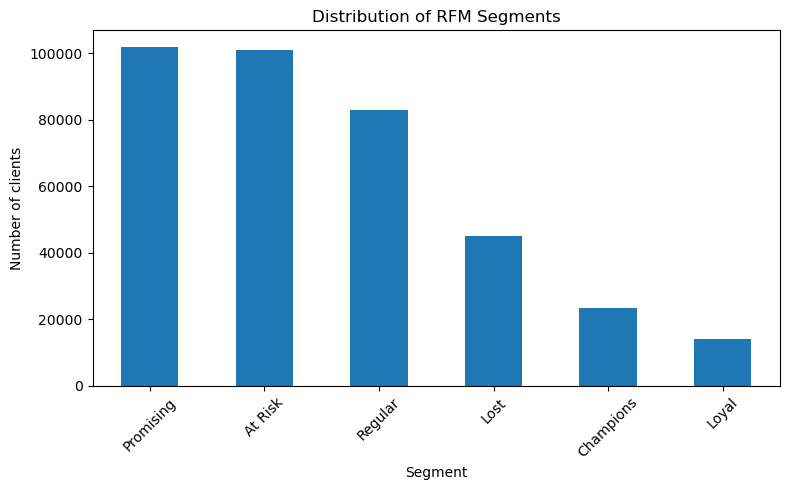

In [11]:
import matplotlib.pyplot as plt

segment_counts = df_rfm['segment'].value_counts()

plt.figure(figsize=(8,5))
segment_counts.plot(kind='bar')

plt.xlabel('Segment')
plt.ylabel('Number of clients')
plt.title('Distribution of RFM Segments')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/var/folders/pk/czrcbd3n6tx7f3m676x_gw700000gn/T/ipykernel_60900/887717572.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


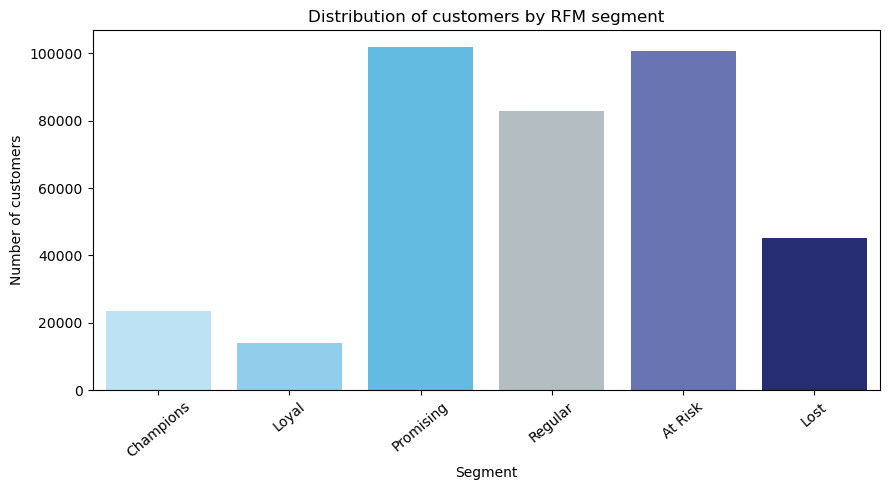

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

colors = [
    '#b3e5fc',  # Champions
    '#81d4fa',  # Loyal
    '#4fc3f7',  # Promising
    '#b0bec5',  # Regular
    '#5c6bc0',  # At Risk
    '#1a237e'   # Lost
]

plt.figure(figsize=(9, 5))

sns.countplot(
    data=df_rfm,
    x='segment',
    order=SEGMENT_ORDER,
    palette=colors
)

plt.xlabel('Segment')
plt.ylabel('Number of customers')
plt.title('Distribution of customers by RFM segment')

plt.xticks(rotation=40)
plt.tight_layout()
plt.show()

In [13]:
train_markov = transitions[transitions['quarter'].isin(quarters[:1])].copy()
test_markov  = transitions[transitions['quarter'] == quarters[1]].copy()

# 4) ML (логистическая регрессия) — берёшь df_rfm со всеми признаками
# и строишь переходы так же, но features остаются:
df_ml = df_rfm.copy()
df_ml['quarter'] = pd.PeriodIndex(df_ml['quarter'], freq='Q')
df_ml = df_ml.sort_values(['Телефон_new','quarter'])
df_ml['segment_next'] = df_ml.groupby('Телефон_new')['segment'].shift(-1)

# тот же split, но уже на df_ml
quarters_sorted = sorted(df_ml['quarter'].unique())
# переходы:
# train: Q1 -> Q2
# test:  Q2 -> Q3
train_quarters = quarters_sorted[:1]    # Q1
test_quarters  = [quarters_sorted[1]]   # Q2

train_ml = df_ml[df_ml['quarter'].isin(train_quarters)].dropna(subset=['segment_next']).copy()
test_ml  = df_ml[df_ml['quarter'].isin(test_quarters)].dropna(subset=['segment_next']).copy()


In [14]:
import pandas as pd

print("=== DATASET SIZES ===")
print("df:", df.shape)
print("df_rfm:", df_rfm.shape)
print("rfm_panel:", rfm_panel.shape)
print("train_markov:", train_markov.shape)
print("test_markov:", test_markov.shape)
print("df_ml:", df_ml.shape)
print("train_ml:", train_ml.shape)
print("test_ml:", test_ml.shape)


print("\n=== UNIQUE CLIENTS ===")
print("df_rfm:", df_rfm['Телефон_new'].nunique())
print("rfm_panel:", rfm_panel['Телефон_new'].nunique())
print("train_ml:", train_ml['Телефон_new'].nunique())
print("test_ml:", test_ml['Телефон_new'].nunique())


print("\n=== QUARTERS IN EACH DATASET ===")
print("df_rfm:", sorted(df_rfm['quarter'].unique()))
print("rfm_panel:", sorted(rfm_panel['quarter'].unique()))
print("train_markov:", sorted(train_markov['quarter'].unique()))
print("test_markov:", sorted(test_markov['quarter'].unique()))
print("train_ml:", sorted(train_ml['quarter'].unique()))
print("test_ml:", sorted(test_ml['quarter'].unique()))


print("\n=== SEGMENT DISTRIBUTION (train_ml) ===")
print(train_ml['segment'].value_counts())

print("\n=== SEGMENT DISTRIBUTION (test_ml) ===")
print(test_ml['segment'].value_counts())


print("\n=== TARGET DISTRIBUTION segment_next (train_ml) ===")
print(train_ml['segment_next'].value_counts())

print("\n=== TARGET DISTRIBUTION segment_next (test_ml) ===")
print(test_ml['segment_next'].value_counts())


print("\n=== NaN CHECK ===")
print("train_ml segment_next NaN:", train_ml['segment_next'].isna().sum())
print("test_ml segment_next NaN:", test_ml['segment_next'].isna().sum())


print("\n=== SAMPLE TRANSITIONS ===")
print(train_ml[['Телефон_new','quarter','segment','segment_next']].head(10))

=== DATASET SIZES ===
df: (368032, 37)
df_rfm: (368032, 43)
rfm_panel: (368032, 9)
train_markov: (35612, 9)
test_markov: (28233, 9)
df_ml: (368032, 44)
train_ml: (35612, 44)
test_ml: (28233, 44)

=== UNIQUE CLIENTS ===
df_rfm: 288943
rfm_panel: 288943
train_ml: 35612
test_ml: 28233

=== QUARTERS IN EACH DATASET ===
df_rfm: ['2017Q1', '2017Q2', '2017Q3', '2017Q4']
rfm_panel: [Period('2017Q1', 'Q-DEC'), Period('2017Q2', 'Q-DEC'), Period('2017Q3', 'Q-DEC'), Period('2017Q4', 'Q-DEC')]
train_markov: [Period('2017Q1', 'Q-DEC')]
test_markov: [Period('2017Q2', 'Q-DEC')]
train_ml: [Period('2017Q1', 'Q-DEC')]
test_ml: [Period('2017Q2', 'Q-DEC')]

=== SEGMENT DISTRIBUTION (train_ml) ===
segment
Promising    12316
At Risk       6574
Champions     6457
Regular       6259
Loyal         2506
Lost          1500
Name: count, dtype: int64

=== SEGMENT DISTRIBUTION (test_ml) ===
segment
Promising    7264
Regular      6674
At Risk      4930
Champions    4704
Loyal        3080
Lost         1581
Name: count

In [15]:
df_ml.head()

,Телефон_new,quarter,total_orders,delivered_ratio,items,most_freq_order_size,cancel_ratio,return_ratio,revenue,margin,avg_order_value,recency_days,days_since_first_purchase,ДЕТСКОЕ ПИТАНИЕ,ЖЕНСКИЕ ШТУЧКИ,ИГРУШКИ,"КАНЦТОВАРЫ, КНИГИ, ДИСКИ",КОСМЕТИКА/ГИГИЕНА,КРУПНОГАБАРИТНЫЙ ТОВАР,ОБУВЬ,ПОДГУЗНИКИ,СОПУТСТВУЮЩИЕ ТОВАРЫ,"ТЕКСТИЛЬ, ТРИКОТАЖ",ТЕХНИКА И ТОВАРЫ ДЛЯ ДОМА,ТОВАРЫ ДЛЯ ЖИВОТНЫХ,ТОВАРЫ ДЛЯ КОРМЛЕНИЯ,CENTRAL,FAR EAST,NORTH,PRIVOLZIE,SIBERIA,SOUTHERN,URAL,delivery_pick point,delivery_курьерская,delivery_самовывоз,payment_безналичная,R_score,F_score,M_score,RFM_sum,RFM_code,segment,segment_next
298186,32555749-545749525150 .,2017Q2,1,1.0,5,5,0.0,0.0,1039.0,174.66,1039.0,84,84,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1,1,2,4,112,Lost,NaN
324788,32565748-535549565054 5,2017Q4,1,1.0,2,2,1.0,0.0,748.0,315.74,748.0,81,81,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1,1,3,5,113,At Risk,NaN
84021,49574954-56524849545119,2017Q3,1,1.0,1,1,0.0,0.0,5166.0,-704.86,5166.0,40,40,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3,1,1,5,311,Regular,NaN
302652,51534957-48525550515032,2017Q3,1,1.0,3,3,0.0,0.0,997.0,262.00,997.0,82,82,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1,1,2,4,112,Lost,NaN
203245,52575753-53554951485345,2017Q1,1,1.0,1,1,0.0,0.0,2208.0,1068.48,2208.0,50,50,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2,1,4,7,214,At Risk,NaN


In [16]:
df_ml[['Телефон_new', 'quarter', 'segment', 'segment_next', 'margin', 'revenue', 'items', 'recency_days', 'avg_order_value', 'delivered_ratio', ]].tail()

,Телефон_new,quarter,segment,segment_next,margin,revenue,items,recency_days,avg_order_value,delivered_ratio
215370,57565349-48535553555395,2017Q1,Regular,NaN,878.00,2070.0,1,48,2070.0,1.0
87827,57565349-55535352575597,2017Q2,Promising,NaN,544.30,4999.0,1,17,4999.0,1.0
336716,57565350-49485256515193,2017Q3,Promising,NaN,47.00,599.0,1,17,599.0,1.0
326602,57565355-57554952485597,2017Q3,Promising,NaN,14.22,720.0,1,17,720.0,1.0
5377,57575757-48485048565195,2017Q1,Promising,NaN,5220.00,24650.0,10,4,24650.0,1.0


In [17]:
ddd = df_ml[['Телефон_new', 'quarter', 'segment', 'segment_next', 'margin', 'revenue', 'items', 'recency_days', 'avg_order_value', 'delivered_ratio', ]].copy()
ddd = ddd.dropna(subset=['segment_next']).copy()

In [18]:
ddd.head()

,Телефон_new,quarter,segment,segment_next,margin,revenue,items,recency_days,avg_order_value,delivered_ratio
159243,55525753-55534957495174,2017Q1,At Risk,At Risk,896.85,2929.0,10,59,2929.0,1.0
3468,55525753-55555057565276,2017Q1,At Risk,Promising,2024.46,28470.0,438,52,9490.0,1.0
554,55525753-55555057565276,2017Q2,Promising,At Risk,1013.60,47040.0,80,8,47040.0,1.0
86795,55525753-57524855525273,2017Q3,Promising,Lost,416.53,5032.0,6,14,2516.0,1.0
220635,55574848-48484848484870,2017Q1,Regular,At Risk,0.50,2000.0,1,53,2000.0,1.0


In [19]:
# Downgrade distribution in train and test
for label, ds in [('Train', train_ml), ('Test', test_ml)]:
    rank_t    = ds['segment'].map(SEGMENT_RANK)
    rank_next = ds['segment_next'].map(SEGMENT_RANK)
    dg = (rank_next < rank_t).astype(int)
    print(f'{label} ({ds["quarter"].iloc[0]}) — n={len(dg):,}')
    print(f'  downgrade=1: {dg.sum():,}  ({dg.mean():.1%})')
    print(f'  downgrade=0: {(1-dg).sum():,}  ({(1-dg).mean():.1%})')
    print()


Train (2017Q1) — n=35,612
  downgrade=1: 16,907  (47.5%)
  downgrade=0: 18,705  (52.5%)

Test (2017Q2) — n=28,233
  downgrade=1: 13,133  (46.5%)
  downgrade=0: 15,100  (53.5%)



# Markov baseline (transition matrix)

In [ ]:
import sys
!{sys.executable} -m pip install -U jinja2

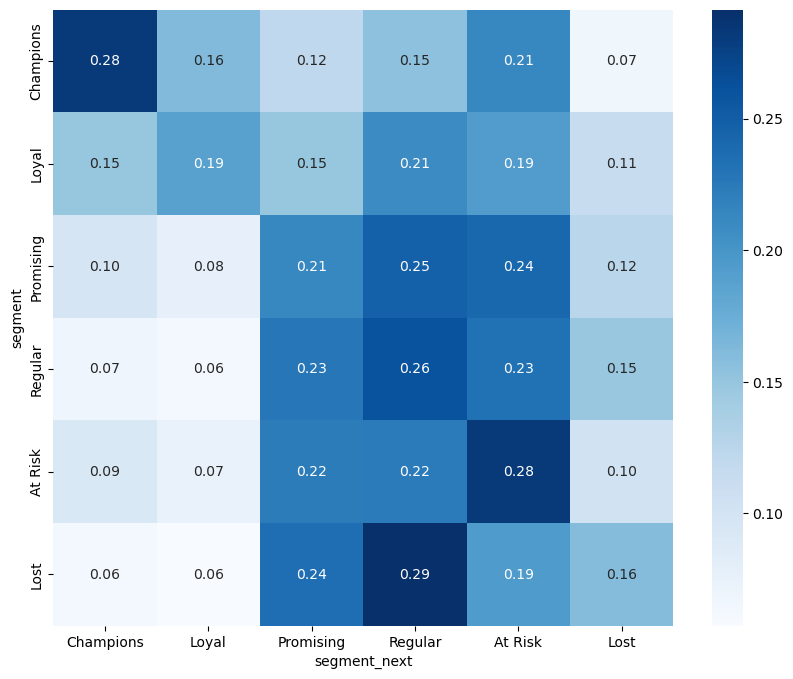

In [20]:
# список всех сегментов (фиксированный порядок из SEGMENT_ORDER)
states = SEGMENT_ORDER

# считаем counts
counts = pd.crosstab(train_markov["segment"], train_markov["segment_next"])

# приводим к полной K×K матрице
counts = counts.reindex(index=states, columns=states, fill_value=0)

# нормируем по строкам → вероятности
row_sums = counts.sum(axis=1)
P_train = counts.div(row_sums, axis=0).fillna(0)

P_train.round(2)

plt.figure(figsize=(10, 8))
sns.heatmap(P_train, annot=True, cmap="Blues", fmt=".2f")
plt.show()

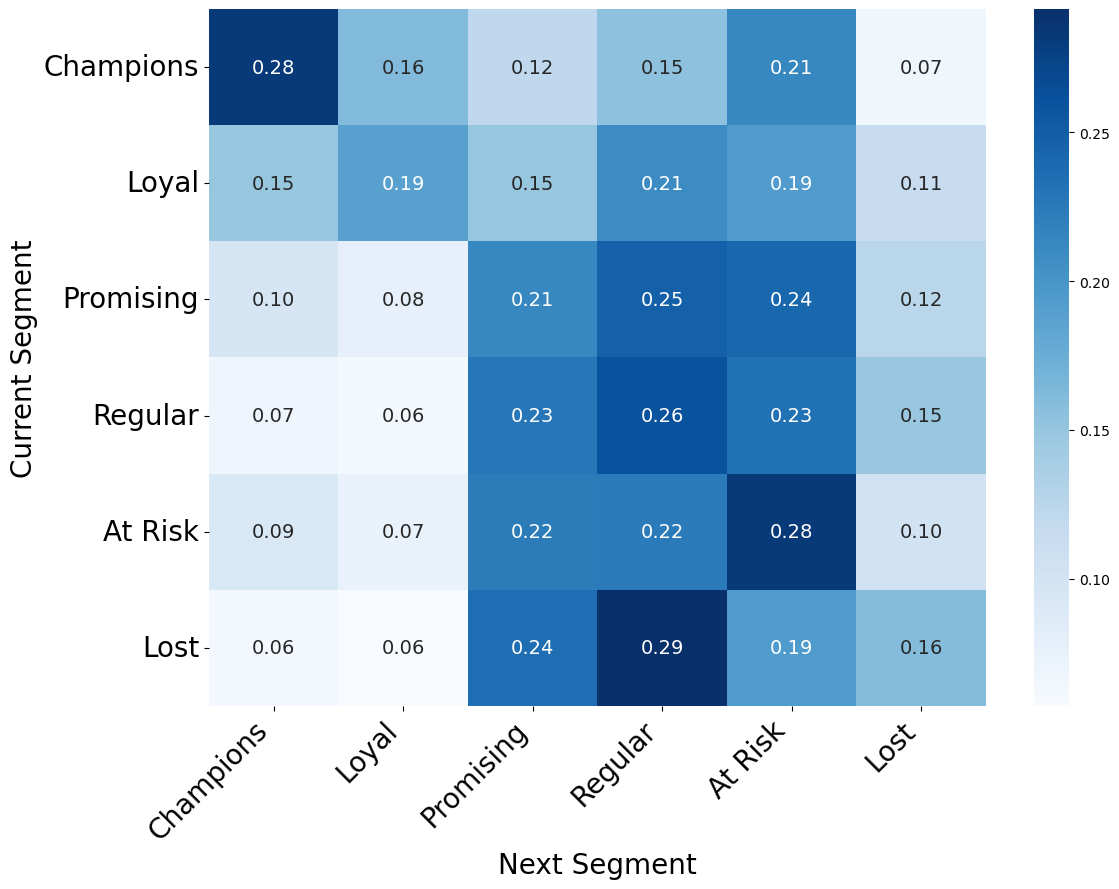

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

states = SEGMENT_ORDER

counts = pd.crosstab(train_markov["segment"], train_markov["segment_next"])
counts = counts.reindex(index=states, columns=states, fill_value=0)

row_sums = counts.sum(axis=1)
P_train = counts.div(row_sums, axis=0).fillna(0)

plt.figure(figsize=(12, 9))

sns.heatmap(
    P_train,
    annot=True,
    cmap="Blues",
    fmt=".2f",
    annot_kws={"size": 14}
)

plt.xlabel("Next Segment", fontsize=20)
plt.ylabel("Current Segment", fontsize=20)
plt.xticks(rotation=45, ha="right", fontsize=20)
plt.yticks(rotation=0, fontsize=20)
plt.tight_layout()
plt.show()

1.	Сегменты умеренно нестабильны.
Диагональные элементы находятся в диапазоне 0.12–0.32, что означает частые переходы между состояниями.
2.	At Risk — центральное состояние системы.
Из большинства сегментов вероятность перехода в At Risk составляет около 20–31%, что указывает на структурный дрейф к снижению активности.
3.	High-value сегменты частично устойчивы.
Champions (0.32) и Loyal (0.29) имеют наибольшую вероятность сохранения статуса, однако риск деградации остаётся значительным.
4.	Big Spenders — нестабильный сегмент.
Вероятность остаться в сегменте низкая (0.13), что может указывать на разовые всплески покупательской активности.
5.	Lost не является поглощающим состоянием.
Существенная доля клиентов возвращается в Regular и Loyal, что означает временную неактивность, а не окончательный churn.

### Accuracy, log-loss

In [22]:
proba = np.vstack([
    P_train.loc[row["segment"]].values
    for _, row in test_markov.iterrows()
])

In [23]:
from sklearn.metrics import accuracy_score

y_true = test_markov["segment_next"].values
y_pred = [states[i] for i in np.argmax(proba, axis=1)]

accuracy = accuracy_score(y_true, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.2267559239188184


In [24]:
from sklearn.metrics import log_loss

# sklearn требует labels в лексикографическом порядке
labels_sorted = sorted(states)
proba_sorted = np.vstack([
    P_train.loc[row["segment"], labels_sorted].values
    for _, row in test_markov.iterrows()
])

logloss = log_loss(y_true, proba_sorted, labels=labels_sorted)

print("Log-loss:", logloss)

Log-loss: 1.7021656452741454


# Bayesian Transition Model

In [25]:
import numpy as np
import pandas as pd

# Матрица счётчиков переходов из train_markov
count_matrix = (
    train_markov
    .groupby(["segment", "segment_next"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=states, columns=states, fill_value=0)
)

# Априорное распределение Дирихле (α=1 — равномерный prior, Laplace smoothing)
alpha_matrix = count_matrix + 1

print("Матрица счётчиков переходов (train):")
count_matrix

Матрица счётчиков переходов (train):


segment_next,Champions,Loyal,Promising,Regular,At Risk,Lost
segment,,,,,,
Champions,1819,1048,779,1000,1379,432
Loyal,373,470,373,522,483,285
Promising,1191,947,2626,3037,2976,1539
Regular,428,392,1425,1632,1454,928
At Risk,607,489,1470,1475,1861,672
Lost,94,86,353,437,291,239


In [26]:
N_SAMPLES = 5000

posterior_samples = {}
for seg in states:
    alpha = alpha_matrix.loc[seg].values.astype(float)
    # Каждая строка — одна выборка вектора вероятностей переходов из seg
    posterior_samples[seg] = np.random.dirichlet(alpha, size=N_SAMPLES)

# Точечная оценка: mean posterior (= alpha / sum(alpha) = MAP для Дирихле)
P_bayes = pd.DataFrame(
    {seg: (alpha_matrix.loc[seg].values / alpha_matrix.loc[seg].values.sum())
     for seg in states},
    index=states
).T

# 90% credible intervals для каждого перехода
ci_low  = pd.DataFrame(
    {seg: np.percentile(posterior_samples[seg], 5, axis=0) for seg in states},
    index=states
).T
ci_high = pd.DataFrame(
    {seg: np.percentile(posterior_samples[seg], 95, axis=0) for seg in states},
    index=states
).T

print("Posterior mean матрица переходов:")
P_bayes.round(3)

Posterior mean матрица переходов:


,Champions,Loyal,Promising,Regular,At Risk,Lost
Champions,0.282,0.162,0.121,0.155,0.214,0.067
Loyal,0.149,0.188,0.149,0.208,0.193,0.114
Promising,0.097,0.077,0.213,0.247,0.242,0.125
Regular,0.068,0.063,0.228,0.261,0.232,0.148
At Risk,0.092,0.074,0.224,0.224,0.283,0.102
Lost,0.063,0.058,0.235,0.291,0.194,0.159


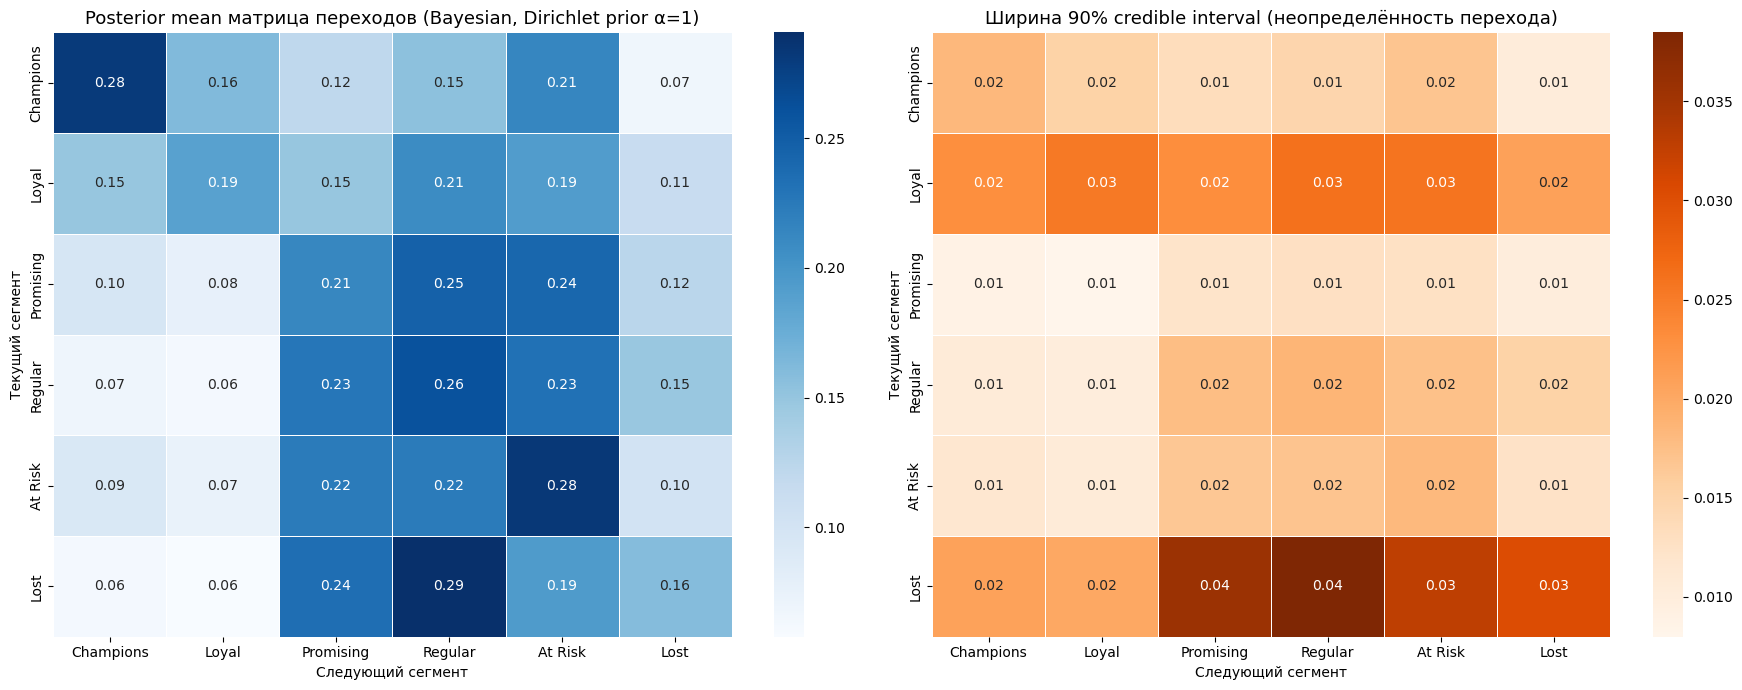

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- 1) Posterior mean ---
sns.heatmap(
    P_bayes.loc[SEGMENT_ORDER, SEGMENT_ORDER],
    annot=True, fmt=".2f", cmap="Blues",
    linewidths=0.5, ax=axes[0]
)
axes[0].set_title("Posterior mean матрица переходов (Bayesian, Dirichlet prior α=1)",
                  fontsize=13)
axes[0].set_xlabel("Следующий сегмент")
axes[0].set_ylabel("Текущий сегмент")

# --- 2) Ширина 90% CI — карта неопределённости ---
uncertainty = (ci_high - ci_low).loc[SEGMENT_ORDER, SEGMENT_ORDER]
sns.heatmap(
    uncertainty,
    annot=True, fmt=".2f", cmap="Oranges",
    linewidths=0.5, ax=axes[1]
)
axes[1].set_title("Ширина 90% credible interval (неопределённость перехода)",
                  fontsize=13)
axes[1].set_xlabel("Следующий сегмент")
axes[1].set_ylabel("Текущий сегмент")

plt.tight_layout()
plt.show()

At Risk — гравитационный центр системы: каждый сегмент уходит туда с вероятностью 0.27–0.37.

Big Spenders — парадокс: самый нестабильный сегмент. 37% уходят в At Risk, только 11% остаются. Это значит крупные покупатели совершают разовые большие покупки и пропадают.

Lost — не поглощающее состояние: 16% остаются в Lost, но 26% уходят в At Risk и 24% в Regular. Это клиенты, которые периодически возвращаются.

count_matrix показывает, где данных мало: у Lost и Big Spenders строки меньше всего наблюдений (2.4k и 5.2k), что подтверждает правомерность Bayesian-сглаживания именно там.

In [28]:
from sklearn.metrics import accuracy_score, log_loss

# sklearn требует labels в лексикографическом порядке
labels_sorted = sorted(states)

proba_bayes = np.vstack([
    P_bayes.loc[row["segment"], labels_sorted].values
    for _, row in test_markov.iterrows()
])
y_pred_bayes = [P_bayes.columns[np.argmax(P_bayes.loc[row["segment"]].values)]
                for _, row in test_markov.iterrows()]

acc_bayes  = accuracy_score(test_markov["segment_next"], y_pred_bayes)
loss_bayes = log_loss(test_markov["segment_next"], proba_bayes, labels=labels_sorted)

comparison = pd.DataFrame({
    "Accuracy": [acc_bayes],
    "Log-loss": [loss_bayes]
}, index=["Bayesian"])

print(comparison.round(4))

          Accuracy  Log-loss
Bayesian    0.2268    1.7022


### Интерпретация

Bayesian transition model расширяет Markov baseline в двух аспектах:

1. **Сглаживание (Laplace prior α=1).** Редкие переходы, которых почти нет в train, получают ненулевую вероятность. Это устраняет проблему нулевых вероятностей при вычислении log-loss.

2. **Карта неопределённости (90% CI).** Широкий credible interval для ячейки (i→j) означает, что данных по переходу из сегмента i слишком мало для уверенной оценки. Узкий CI — переход наблюдается стабильно и его вероятность хорошо оценена. Это помогает понять, каким переходам в матрице можно доверять, а какие остаются неопределёнными.

**Вывод:** метрики (accuracy, log-loss) у Bayesian и Markov близки, потому что точечная оценка совпадает при большом объёме данных. Главная ценность Bayesian-подхода — явная квантификация неопределённости переходов, что недоступно в классическом Markov baseline.

# Multiclass Next-Segment Prediction

In [ ]:
train_ml.head(1)

In [ ]:
test_ml.head(1)

In [ ]:
train_ml['quarter'].value_counts()

In [ ]:
test_ml['quarter'].value_counts()

In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler

y_train = train_ml['segment_next'].copy()
y_test  = test_ml['segment_next'].copy()

In [ ]:
# 2) ONE-HOT ENCODE SEGMENT

seg_ohe = OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False)

seg_train = seg_ohe.fit_transform(train_ml[['segment']])
seg_test  = seg_ohe.transform(test_ml[['segment']])

seg_cols = [f"segment_{c}" for c in seg_ohe.categories_[0][1:]]

seg_train_df = pd.DataFrame(seg_train, columns=seg_cols, index=train_ml.index)
seg_test_df  = pd.DataFrame(seg_test, columns=seg_cols, index=test_ml.index)

In [ ]:
# 3) FEATURE MATRIX

base_feature_cols = [
    'total_orders', 'delivered_ratio', 'items', 'most_freq_order_size',
    'cancel_ratio', 'return_ratio', 'revenue', 'margin', 'avg_order_value',
    'recency_days', 'days_since_first_purchase',

    'ДЕТСКОЕ ПИТАНИЕ', 'ЖЕНСКИЕ ШТУЧКИ', 'ИГРУШКИ',
    'КАНЦТОВАРЫ, КНИГИ, ДИСКИ', 'КОСМЕТИКА/ГИГИЕНА',
    'КРУПНОГАБАРИТНЫЙ ТОВАР', 'ОБУВЬ', 'ПОДГУЗНИКИ',
    'СОПУТСТВУЮЩИЕ ТОВАРЫ', 'ТЕКСТИЛЬ, ТРИКОТАЖ',
    'ТЕХНИКА И ТОВАРЫ ДЛЯ ДОМА', 'ТОВАРЫ ДЛЯ ЖИВОТНЫХ',
    'ТОВАРЫ ДЛЯ КОРМЛЕНИЯ',

    'CENTRAL', 'FAR EAST', 'NORTH', 'PRIVOLZIE',
    'SIBERIA', 'SOUTHERN', 'URAL',

    'delivery_pick point', 'delivery_курьерская',
    'delivery_самовывоз', 'payment_безналичная',
]

X_train = pd.concat(
    [train_ml[base_feature_cols].copy(), seg_train_df],
    axis=1
)

X_test = pd.concat(
    [test_ml[base_feature_cols].copy(), seg_test_df],
    axis=1
)

In [ ]:
train_ml.isna().sum()

In [ ]:
X_test.isna().sum()

In [ ]:
# 4) PREPROCESSING (fixed: log1p-domain NaNs + dtype warnings)

import numpy as np
from sklearn.preprocessing import RobustScaler, StandardScaler

heavy_tail = [
    'items',
    'revenue',
    'margin',
    'avg_order_value',
    'most_freq_order_size'
]

standard_features = [
    'delivered_ratio',
    'cancel_ratio',
    'return_ratio',
    'recency_days'
]

# ---- ensure float dtype for columns we transform (fixes pandas FutureWarning)
for col in set(heavy_tail + standard_features):
    if col in X_train.columns:
        X_train.loc[:, col] = X_train[col].astype(float)
        X_test.loc[:, col]  = X_test[col].astype(float)

# ---- margin shift (fit only on train) + protect log1p domain on test (fixes new NaNs)
if 'margin' in X_train.columns:
    margin_shift = -X_train['margin'].min() + 1.0  # ensure float
    X_train.loc[:, 'margin'] = X_train['margin'] + margin_shift
    X_test.loc[:, 'margin']  = X_test['margin'] + margin_shift

    # after train-based shift, test can still be < -1 if test has lower min than train
    # clip to keep log1p valid
    X_test.loc[:, 'margin'] = X_test['margin'].clip(lower=0.0)

# ---- log1p heavy tail (safe: clip to valid domain)
for col in heavy_tail:
    if col in X_train.columns:
        # If any feature can be negative (rare but possible due to data issues), guard the domain.
        # For margin we already clipped test; for others we clip both just in case.
        X_train.loc[:, col] = np.log1p(X_train[col].clip(lower=0.0))
        X_test.loc[:, col]  = np.log1p(X_test[col].clip(lower=0.0))

# ---- optional clipping (still uses train quantiles)
DO_CLIP = False
CLIP_Q = 0.995

if DO_CLIP:
    for col in heavy_tail:
        if col in X_train.columns:
            upper = X_train[col].quantile(CLIP_Q)
            X_train.loc[:, col] = X_train[col].clip(upper=upper)
            X_test.loc[:, col]  = X_test[col].clip(upper=upper)

# ---- scaling
ht_cols = [c for c in heavy_tail if c in X_train.columns]
sf_cols = [c for c in standard_features if c in X_train.columns]

if ht_cols:
    robust_scaler = RobustScaler()
    X_train.loc[:, ht_cols] = robust_scaler.fit_transform(X_train[ht_cols])
    X_test.loc[:, ht_cols]  = robust_scaler.transform(X_test[ht_cols])

if sf_cols:
    std_scaler = StandardScaler()
    X_train.loc[:, sf_cols] = std_scaler.fit_transform(X_train[sf_cols])
    X_test.loc[:, sf_cols]  = std_scaler.transform(X_test[sf_cols])

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print("OHE columns:", len(seg_cols))

# sanity check: no NaNs introduced
print("NaNs in X_train:", int(X_train.isna().sum().sum()))
print("NaNs in X_test:", int(X_test.isna().sum().sum()))

In [ ]:
X_test.isna().sum()

In [ ]:
X_test.head(2)

In [ ]:
y_train.head()

In [ ]:
y_test.head()

In [ ]:
X_train.columns

In [ ]:
# train_ml = train_ml.dropna()
# test_ml = test_ml.dropna()

In [ ]:
X_test.isna().sum()

## Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=1000,
    n_jobs=-1
)

logreg.fit(X_train, y_train)

In [ ]:
y_pred = logreg.predict(X_test)
y_proba = logreg.predict_proba(X_test)

In [ ]:
from sklearn.metrics import log_loss

y_proba = logreg.predict_proba(X_test)
ll = log_loss(y_test, y_proba, labels=logreg.classes_)

print("Log Loss:", ll)


In [ ]:
from sklearn.metrics import accuracy_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average="macro")

print("Accuracy:", accuracy)
print("Macro F1:", f1_macro)

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=logreg.classes_)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=logreg.classes_,
            yticklabels=logreg.classes_,
            cmap="Blues")

plt.xlabel("Predicted segment")
plt.ylabel("True segment")
plt.title("Confusion Matrix: Logistic Regression")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

In [ ]:
coef_df = pd.DataFrame(
    logreg.coef_,
    columns=X_train.columns,
    index=logreg.classes_
)

coef_df.head()

## LightGBM

In [ ]:
# pip install lightgbm

In [ ]:
import sys
print(sys.executable)

In [ ]:
# import sys
# !{sys.executable} -m pip uninstall -y dask distributed lightgbm
# !{sys.executable} -m pip install -U "dask[dataframe]>=2023.2.0" "distributed>=2023.2.0" "lightgbm>=4.0"

In [ ]:
rename_dict = {

"ДЕТСКОЕ ПИТАНИЕ": "cat_baby_food",
"ЖЕНСКИЕ ШТУЧКИ": "cat_women_goods",
"ИГРУШКИ": "cat_toys",
"КАНЦТОВАРЫ, КНИГИ, ДИСКИ": "cat_stationery_books",
"КОСМЕТИКА/ГИГИЕНА": "cat_cosmetics_hygiene",
"КРУПНОГАБАРИТНЫЙ ТОВАР": "cat_large_goods",
"ОБУВЬ": "cat_shoes",
"ПОДГУЗНИКИ": "cat_diapers",
"СОПУТСТВУЮЩИЕ ТОВАРЫ": "cat_accessories",
"ТЕКСТИЛЬ, ТРИКОТАЖ": "cat_textile",
"ТЕХНИКА И ТОВАРЫ ДЛЯ ДОМА": "cat_home_tech",
"ТОВАРЫ ДЛЯ ЖИВОТНЫХ": "cat_pet_goods",
"ТОВАРЫ ДЛЯ КОРМЛЕНИЯ": "cat_feeding_goods",

"FAR EAST": "region_far_east",

"delivery_pick point": "delivery_pickup_point",
"delivery_курьерская": "delivery_courier",
"delivery_самовывоз": "delivery_self_pickup",

"payment_безналичная": "payment_cashless",

"segment_Champions":  "segment_champions",
"segment_Loyal":      "segment_loyal",
"segment_Promising":  "segment_promising",
"segment_Regular":    "segment_regular",
"segment_At Risk":    "segment_at_risk",
"segment_Lost":       "segment_lost",

}

X_train = X_train.rename(columns=rename_dict)
X_test = X_test.rename(columns=rename_dict)

In [ ]:
X_train.columns

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, log_loss, f1_score

model = LGBMClassifier(
    objective="multiclass",
    num_class=len(y_train.unique()),
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)

In [ ]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

In [ ]:
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="macro")
ll = log_loss(y_test, y_pred_proba, labels=logreg.classes_)

print("Accuracy:", acc)
print("Macro-F1:", f1)
print("Log-loss:", ll)

In [ ]:
import pandas as pd

importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance.head(60))

In [ ]:
# Удаляем неважные признаки (отбор по важности признаков)
drop_cols = [
    "segment_loyal",
    "segment_regular",
    "segment_champions",
    "segment_promising",
    "segment_at_risk",
    "segment_lost",
    "region_far_east",
    "SOUTHERN",
    "SIBERIA",
    "URAL",
    "NORTH",
    "PRIVOLZIE",
    "CENTRAL",
    "cat_home_tech",
    "cat_women_goods",
    "cat_accessories"
]

X_train_reduced = X_train.drop(columns=drop_cols, errors="ignore")
X_test_reduced = X_test.drop(columns=drop_cols, errors="ignore")

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, log_loss, f1_score

model = LGBMClassifier(
    objective="multiclass",
    num_class=len(y_train.unique()),
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

model.fit(X_train_reduced, y_train)

y_pred = model.predict(X_test_reduced)
y_pred_proba = model.predict_proba(X_test_reduced)

In [ ]:
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="macro")
ll = log_loss(y_test, y_pred_proba)

print("Accuracy:", acc)
print("Macro-F1:", f1)
print("Log-loss:", ll)

In [ ]:
import pandas as pd

importance = pd.Series(
    model.feature_importances_,
    index=X_train_reduced.columns
).sort_values(ascending=False)

print(importance.head(60))

In [ ]:
from sklearn.metrics import confusion_matrix
import pandas as pd

# список сегментов в фиксированном порядке
labels = sorted(y_test.unique())

cm = confusion_matrix(y_test, y_pred, labels=labels)

cm_df = pd.DataFrame(cm, index=labels, columns=labels)

print(cm_df)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    cm_df,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted segment")
plt.ylabel("True segment")
plt.title("Confusion Matrix of Segment Transition Prediction")

plt.show()

In [ ]:
cm_norm = cm / cm.sum(axis=1, keepdims=True)

cm_norm_df = pd.DataFrame(cm_norm, index=labels, columns=labels)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm_norm_df,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.xlabel("Predicted segment")
plt.ylabel("True segment")
plt.title("Normalized Confusion Matrix")

plt.show()

# Binary classification of downgrade

In [29]:
train_ml.head()

,Телефон_new,quarter,total_orders,delivered_ratio,items,most_freq_order_size,cancel_ratio,return_ratio,revenue,margin,avg_order_value,recency_days,days_since_first_purchase,ДЕТСКОЕ ПИТАНИЕ,ЖЕНСКИЕ ШТУЧКИ,ИГРУШКИ,"КАНЦТОВАРЫ, КНИГИ, ДИСКИ",КОСМЕТИКА/ГИГИЕНА,КРУПНОГАБАРИТНЫЙ ТОВАР,ОБУВЬ,ПОДГУЗНИКИ,СОПУТСТВУЮЩИЕ ТОВАРЫ,"ТЕКСТИЛЬ, ТРИКОТАЖ",ТЕХНИКА И ТОВАРЫ ДЛЯ ДОМА,ТОВАРЫ ДЛЯ ЖИВОТНЫХ,ТОВАРЫ ДЛЯ КОРМЛЕНИЯ,CENTRAL,FAR EAST,NORTH,PRIVOLZIE,SIBERIA,SOUTHERN,URAL,delivery_pick point,delivery_курьерская,delivery_самовывоз,payment_безналичная,R_score,F_score,M_score,RFM_sum,RFM_code,segment,segment_next
159243,55525753-55534957495174,2017Q1,1,1.00,10,10,0.000000,0.0,2929.0,896.85,2929.000000,59,59,0.0,0.0,0.500000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.500000,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2,1,4,7,214,At Risk,At Risk
3468,55525753-55555057565276,2017Q1,3,1.00,438,100,0.000000,0.0,28470.0,2024.46,9490.000000,52,78,1.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2,3,5,10,235,At Risk,Promising
220635,55574848-48484848484870,2017Q1,1,1.00,1,1,0.000000,0.0,2000.0,0.50,2000.000000,53,53,0.0,0.0,0.000000,0.0,0.0,0.0,1.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2,1,1,4,211,Regular,At Risk
51921,55574848-48494948544878,2017Q1,4,0.75,19,2,0.250000,0.0,7291.0,978.95,2430.333333,10,79,0.0,0.0,0.315789,0.0,0.0,0.0,0.000000,0.052632,0.0,0.631579,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,5,3,4,12,534,Champions,At Risk
58598,55574848-48495057545270,2017Q1,3,1.00,13,3,0.333333,0.0,6710.0,2417.02,2236.666667,30,79,0.0,0.0,0.000000,0.0,0.0,0.0,0.076923,0.000000,0.0,0.923077,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3,3,5,11,335,Loyal,Promising


In [30]:
train_ml['quarter'].value_counts()

quarter
2017Q1    35612
Freq: Q-DEC, Name: count, dtype: int64

In [31]:
import pandas as pd
import numpy as np

train_bin = train_ml.copy()
test_bin  = test_ml.copy()

# Ранги берём из единого словаря SEGMENT_RANK (определён в ячейке add_rfm_and_segment)
train_bin["rank_t"]    = train_bin["segment"].map(SEGMENT_RANK)
train_bin["rank_next"] = train_bin["segment_next"].map(SEGMENT_RANK)

test_bin["rank_t"]    = test_bin["segment"].map(SEGMENT_RANK)
test_bin["rank_next"] = test_bin["segment_next"].map(SEGMENT_RANK)

train_bin["downgrade"] = (train_bin["rank_next"] < train_bin["rank_t"]).astype(int)
test_bin["downgrade"]  = (test_bin["rank_next"]  < test_bin["rank_t"]).astype(int)

print("Train downgrade rate:")
print(train_bin["downgrade"].value_counts(normalize=True))

print("\nTest downgrade rate:")
print(test_bin["downgrade"].value_counts(normalize=True))

Train downgrade rate:
downgrade
0    0.525244
1    0.474756
Name: proportion, dtype: float64

Test downgrade rate:
downgrade
0    0.534835
1    0.465165
Name: proportion, dtype: float64


In [32]:
# Разбивка downgrade по каждому переходу отдельно
for q in sorted(train_ml['quarter'].unique().tolist() + test_ml['quarter'].unique().tolist()):
    subset = df_ml[df_ml['quarter'] == q].copy()
    subset['rank_t']    = subset['segment'].map(SEGMENT_RANK)
    subset['rank_next'] = subset['segment_next'].map(SEGMENT_RANK)
    subset = subset.dropna(subset=['rank_t', 'rank_next'])
    dg_rate = (subset['rank_next'] < subset['rank_t']).mean()
    print(f"{q} → next: downgrade rate = {dg_rate:.3f}  (n={len(subset)})")

# Распределение сегментов по кварталам
print("\nСегменты по кварталам:")
print(df_rfm.groupby('quarter')['segment'].value_counts(normalize=True).unstack().round(2))


2017Q1 → next: downgrade rate = 0.475  (n=35612)
2017Q2 → next: downgrade rate = 0.465  (n=28233)

Сегменты по кварталам:
segment  At Risk  Champions  Lost  Loyal  Promising  Regular
quarter                                                     
2017Q1      0.24       0.08  0.06   0.04       0.35     0.23
2017Q2      0.23       0.07  0.09   0.06       0.26     0.30
2017Q3      0.24       0.07  0.09   0.03       0.34     0.23
2017Q4      0.52        NaN  0.41   0.00        NaN     0.07


In [33]:
print(df_rfm[df_rfm['quarter'] == '2017Q4']['recency_days'].describe())
print(df_rfm[df_rfm['quarter'] != '2017Q4']['recency_days'].describe())


count    49224.000000
mean        77.688343
std          8.699408
min         30.000000
25%         73.000000
50%         78.000000
75%         84.000000
max         91.000000
Name: recency_days, dtype: float64
count    318808.000000
mean         41.065563
std          26.245688
min           0.000000
25%          17.000000
50%          40.000000
75%          64.000000
max          91.000000
Name: recency_days, dtype: float64


In [34]:
train_bin.head(1)

,Телефон_new,quarter,total_orders,delivered_ratio,items,most_freq_order_size,cancel_ratio,return_ratio,revenue,margin,avg_order_value,recency_days,days_since_first_purchase,ДЕТСКОЕ ПИТАНИЕ,ЖЕНСКИЕ ШТУЧКИ,ИГРУШКИ,"КАНЦТОВАРЫ, КНИГИ, ДИСКИ",КОСМЕТИКА/ГИГИЕНА,КРУПНОГАБАРИТНЫЙ ТОВАР,ОБУВЬ,ПОДГУЗНИКИ,СОПУТСТВУЮЩИЕ ТОВАРЫ,"ТЕКСТИЛЬ, ТРИКОТАЖ",ТЕХНИКА И ТОВАРЫ ДЛЯ ДОМА,ТОВАРЫ ДЛЯ ЖИВОТНЫХ,ТОВАРЫ ДЛЯ КОРМЛЕНИЯ,CENTRAL,FAR EAST,NORTH,PRIVOLZIE,SIBERIA,SOUTHERN,URAL,delivery_pick point,delivery_курьерская,delivery_самовывоз,payment_безналичная,R_score,F_score,M_score,RFM_sum,RFM_code,segment,segment_next,rank_t,rank_next,downgrade
159243,55525753-55534957495174,2017Q1,1,1.0,10,10,0.0,0.0,2929.0,896.85,2929.0,59,59,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2,1,4,7,214,At Risk,At Risk,1,1,0


In [35]:
test_bin.head(1)

,Телефон_new,quarter,total_orders,delivered_ratio,items,most_freq_order_size,cancel_ratio,return_ratio,revenue,margin,avg_order_value,recency_days,days_since_first_purchase,ДЕТСКОЕ ПИТАНИЕ,ЖЕНСКИЕ ШТУЧКИ,ИГРУШКИ,"КАНЦТОВАРЫ, КНИГИ, ДИСКИ",КОСМЕТИКА/ГИГИЕНА,КРУПНОГАБАРИТНЫЙ ТОВАР,ОБУВЬ,ПОДГУЗНИКИ,СОПУТСТВУЮЩИЕ ТОВАРЫ,"ТЕКСТИЛЬ, ТРИКОТАЖ",ТЕХНИКА И ТОВАРЫ ДЛЯ ДОМА,ТОВАРЫ ДЛЯ ЖИВОТНЫХ,ТОВАРЫ ДЛЯ КОРМЛЕНИЯ,CENTRAL,FAR EAST,NORTH,PRIVOLZIE,SIBERIA,SOUTHERN,URAL,delivery_pick point,delivery_курьерская,delivery_самовывоз,payment_безналичная,R_score,F_score,M_score,RFM_sum,RFM_code,segment,segment_next,rank_t,rank_next,downgrade
554,55525753-55555057565276,2017Q2,1,1.0,80,80,0.0,0.0,47040.0,1013.6,47040.0,8,169,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,5,1,4,10,514,Promising,At Risk,3,1,1


In [36]:
from sklearn.preprocessing import OneHotEncoder

In [37]:
rename_dict = {
    "ДЕТСКОЕ ПИТАНИЕ": "cat_baby_food",
    "ЖЕНСКИЕ ШТУЧКИ": "cat_women_goods",
    "ИГРУШКИ": "cat_toys",
    "КАНЦТОВАРЫ, КНИГИ, ДИСКИ": "cat_stationery_books",
    "КОСМЕТИКА/ГИГИЕНА": "cat_cosmetics_hygiene",
    "КРУПНОГАБАРИТНЫЙ ТОВАР": "cat_large_goods",
    "ОБУВЬ": "cat_shoes",
    "ПОДГУЗНИКИ": "cat_diapers",
    "СОПУТСТВУЮЩИЕ ТОВАРЫ": "cat_accessories",
    "ТЕКСТИЛЬ, ТРИКОТАЖ": "cat_textile",
    "ТЕХНИКА И ТОВАРЫ ДЛЯ ДОМА": "cat_home_tech",
    "ТОВАРЫ ДЛЯ ЖИВОТНЫХ": "cat_pet_goods",
    "ТОВАРЫ ДЛЯ КОРМЛЕНИЯ": "cat_feeding_goods",
    "FAR EAST": "region_far_east",
    "delivery_pick point": "delivery_pickup_point",
    "delivery_курьерская": "delivery_courier",
    "delivery_самовывоз": "delivery_self_pickup",
    "payment_безналичная": "payment_cashless",
    "segment_Champions":  "segment_champions",
    "segment_Loyal":      "segment_loyal",
    "segment_Promising":  "segment_promising",
    "segment_Regular":    "segment_regular",
    "segment_At Risk":    "segment_at_risk",
    "segment_Lost":       "segment_lost",
}

train_bin = train_bin.rename(columns=rename_dict)
test_bin = test_bin.rename(columns=rename_dict)

# OHE текущего сегмента — drop=None, все 6 dummy (деревьям multicollinearity не мешает)
seg_bin_ohe = OneHotEncoder(handle_unknown="ignore", drop=None, sparse_output=False)
seg_bin_train = seg_bin_ohe.fit_transform(train_bin[["segment"]])
seg_bin_test  = seg_bin_ohe.transform(test_bin[["segment"]])
seg_bin_cols  = [f"segment_{c}" for c in seg_bin_ohe.categories_[0]]

seg_bin_train_df = pd.DataFrame(seg_bin_train, columns=seg_bin_cols, index=train_bin.index)
seg_bin_test_df  = pd.DataFrame(seg_bin_test,  columns=seg_bin_cols, index=test_bin.index)

train_bin = pd.concat([train_bin, seg_bin_train_df], axis=1)
test_bin  = pd.concat([test_bin,  seg_bin_test_df],  axis=1)


In [38]:
target_col = "downgrade"

drop_cols = [
    "Телефон_new",
    "quarter",
    "segment",
    "segment_next",
    "rank_t",
    "rank_next",
    target_col,
    "RFM_code",
    'R_score',
    'F_score',
    'M_score',
    'RFM_sum'
]

X_train_bin = train_bin.drop(columns=drop_cols, errors="ignore")
y_train_bin = train_bin[target_col]

X_test_bin = test_bin.drop(columns=drop_cols, errors="ignore")
y_test_bin = test_bin[target_col]

print(X_train_bin.shape, X_test_bin.shape)
print(y_train_bin.value_counts(normalize=True))


(35612, 41) (28233, 41)
downgrade
0    0.525244
1    0.474756
Name: proportion, dtype: float64


In [39]:
X_train_bin.shape

(35612, 41)

In [40]:
X_train_bin.head(1)

,total_orders,delivered_ratio,items,most_freq_order_size,cancel_ratio,return_ratio,revenue,margin,avg_order_value,recency_days,days_since_first_purchase,cat_baby_food,cat_women_goods,cat_toys,cat_stationery_books,cat_cosmetics_hygiene,cat_large_goods,cat_shoes,cat_diapers,cat_accessories,cat_textile,cat_home_tech,cat_pet_goods,cat_feeding_goods,CENTRAL,region_far_east,NORTH,PRIVOLZIE,SIBERIA,SOUTHERN,URAL,delivery_pickup_point,delivery_courier,delivery_self_pickup,payment_cashless,segment_At Risk,segment_Champions,segment_Lost,segment_Loyal,segment_Promising,segment_Regular
159243,1,1.0,10,10,0.0,0.0,2929.0,896.85,2929.0,59,59,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [41]:
y_train_bin.head()

159243    0
3468      0
220635    1
51921     1
58598     1
Name: downgrade, dtype: int64

### Logistic regression

In [42]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logreg_bin = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=42
    ))
])

logreg_bin.fit(X_train_bin, y_train_bin)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

logreg_bin = LogisticRegression(
    max_iter=4000,
    class_weight="balanced",
    random_state=42
)

logreg_bin.fit(X_train_bin, y_train_bin)

y_pred_bin = logreg_bin.predict(X_test_bin)
y_prob_bin = logreg_bin.predict_proba(X_test_bin)[:, 1]

print("Binary downgrade — Logistic Regression")
print("Accuracy:", accuracy_score(y_test_bin, y_pred_bin))
print("F1:", f1_score(y_test_bin, y_pred_bin))
print("ROC-AUC:", roc_auc_score(y_test_bin, y_prob_bin))
print()
print(classification_report(y_test_bin, y_pred_bin, digits=3))

Binary downgrade — Logistic Regression
Accuracy: 0.6812949385470903
F1: 0.6747632473071641
ROC-AUC: 0.7456573854952113

              precision    recall  f1-score   support

           0      0.723     0.656     0.688     15100
           1      0.642     0.711     0.675     13133

    accuracy                          0.681     28233
   macro avg      0.682     0.683     0.681     28233
weighted avg      0.685     0.681     0.682     28233



/Users/dl3/anaconda3/envs/py312/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 4000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=4000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


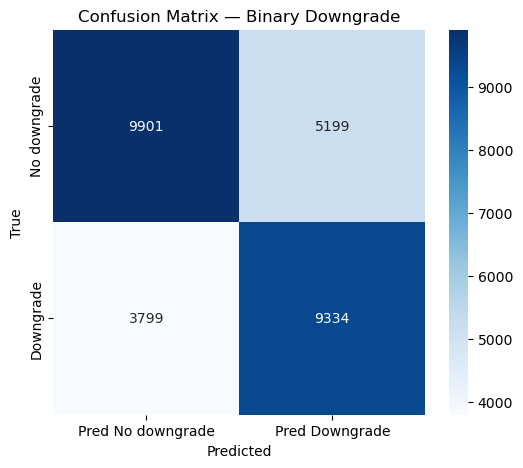

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_bin, y_pred_bin)
cm_df = pd.DataFrame(
    cm,
    index=["No downgrade", "Downgrade"],
    columns=["Pred No downgrade", "Pred Downgrade"]
)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix — Binary Downgrade")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.show()

In [45]:
# --- Logistic Regression: оптимизация порога ---
from sklearn.metrics import precision_recall_curve, f1_score, recall_score, precision_score, roc_auc_score

prec_lr, rec_lr, thr_lr = precision_recall_curve(y_test_bin, y_prob_bin)
f1_lr_arr  = 2 * (prec_lr * rec_lr) / (prec_lr + rec_lr + 1e-8)
best_thr_lr = thr_lr[f1_lr_arr[:-1].argmax()]
y_pred_lr_opt = (y_prob_bin >= best_thr_lr).astype(int)

print(f"Optimal threshold (LR): {best_thr_lr:.4f}")
print(f"\n=== Logistic Regression — opt threshold ===")
print(f"ROC AUC:   {roc_auc_score(y_test_bin, y_prob_bin):.3f}")
print(f"F1:        {f1_score(y_test_bin, y_pred_lr_opt):.3f}")
print(f"Recall:    {recall_score(y_test_bin, y_pred_lr_opt):.3f}")
print(f"Precision: {precision_score(y_test_bin, y_pred_lr_opt):.3f}")


Optimal threshold (LR): 0.2061

=== Logistic Regression — opt threshold ===
ROC AUC:   0.746
F1:        0.715
Recall:    0.946
Precision: 0.574


### Light GBM

In [46]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, log_loss, f1_score, roc_auc_score
from sklearn.metrics import classification_report

lgbm_bin = LGBMClassifier(
    objective="binary",
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=15,
    max_depth=5,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    class_weight="balanced",
    random_state=42,
    force_row_wise=True,
    verbose=-1
)

lgbm_bin.fit(X_train_bin, y_train_bin)

y_pred_lgbm = lgbm_bin.predict(X_test_bin)
y_prob_lgbm = lgbm_bin.predict_proba(X_test_bin)[:, 1]

print("Binary downgrade — LightGBM")
print("Accuracy:", accuracy_score(y_test_bin, y_pred_lgbm))
print("F1:", f1_score(y_test_bin, y_pred_lgbm))
print("ROC-AUC:", roc_auc_score(y_test_bin, y_prob_lgbm))
print()
print(classification_report(y_test_bin, y_pred_lgbm, digits=3))

Binary downgrade — LightGBM
Accuracy: 0.686395352955761
F1: 0.6797366707661144
ROC-AUC: 0.7577158923756595

              precision    recall  f1-score   support

           0      0.728     0.661     0.693     15100
           1      0.647     0.715     0.680     13133

    accuracy                          0.686     28233
   macro avg      0.688     0.688     0.686     28233
weighted avg      0.690     0.686     0.687     28233



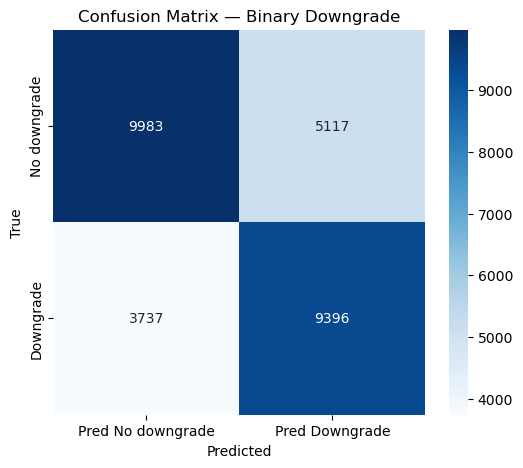

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_bin, y_pred_lgbm)
cm_df = pd.DataFrame(
    cm,
    index=["No downgrade", "Downgrade"],
    columns=["Pred No downgrade", "Pred Downgrade"]
)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix — Binary Downgrade")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.show()

In [48]:
# --- LightGBM: оптимизация порога ---
from sklearn.metrics import precision_recall_curve, f1_score, recall_score, precision_score, roc_auc_score

prec_lgbm, rec_lgbm, thr_lgbm = precision_recall_curve(y_test_bin, y_prob_lgbm)
f1_lgbm_arr  = 2 * (prec_lgbm * rec_lgbm) / (prec_lgbm + rec_lgbm + 1e-8)
best_thr_lgbm = thr_lgbm[f1_lgbm_arr[:-1].argmax()]
y_pred_lgbm_opt = (y_prob_lgbm >= best_thr_lgbm).astype(int)

print(f"Optimal threshold (LightGBM): {best_thr_lgbm:.4f}")
print(f"\n=== LightGBM — opt threshold ===")
print(f"ROC AUC:   {roc_auc_score(y_test_bin, y_prob_lgbm):.3f}")
print(f"F1:        {f1_score(y_test_bin, y_pred_lgbm_opt):.3f}")
print(f"Recall:    {recall_score(y_test_bin, y_pred_lgbm_opt):.3f}")
print(f"Precision: {precision_score(y_test_bin, y_pred_lgbm_opt):.3f}")


Optimal threshold (LightGBM): 0.3201

=== LightGBM — opt threshold ===
ROC AUC:   0.758
F1:        0.715
Recall:    0.942
Precision: 0.576


In [49]:
# Найти клиентов с высоким риском downgrade
test_scores = test_bin.copy()
test_scores["p_downgrade"] = y_prob_lgbm

risk_clients = test_scores[
    ["Телефон_new", "quarter", "segment", "segment_next", "downgrade", "p_downgrade"]
].sort_values("p_downgrade", ascending=False)

risk_clients.head(10)

,Телефон_new,quarter,segment,segment_next,downgrade,p_downgrade
7389,55575055-48534851535378,2017Q2,Champions,Lost,1,0.920203
11270,55575650-57515656565772,2017Q2,Champions,Lost,1,0.917509
47945,55574853-56514850485571,2017Q2,Champions,Promising,1,0.916676
271904,55575050-50545152565770,2017Q2,Champions,At Risk,1,0.914238
36168,55575456-55495256564978,2017Q2,Champions,Promising,1,0.911075
1084,55575050-55575651535573,2017Q2,Champions,At Risk,1,0.910368
183491,55575348-48535451505578,2017Q2,Champions,Champions,0,0.909719
8043,55575054-53525148485175,2017Q2,Champions,Promising,1,0.908577
89332,55574951-50484957525675,2017Q2,Champions,At Risk,1,0.908264
161741,55574957-54495055525771,2017Q2,Champions,Champions,0,0.908047


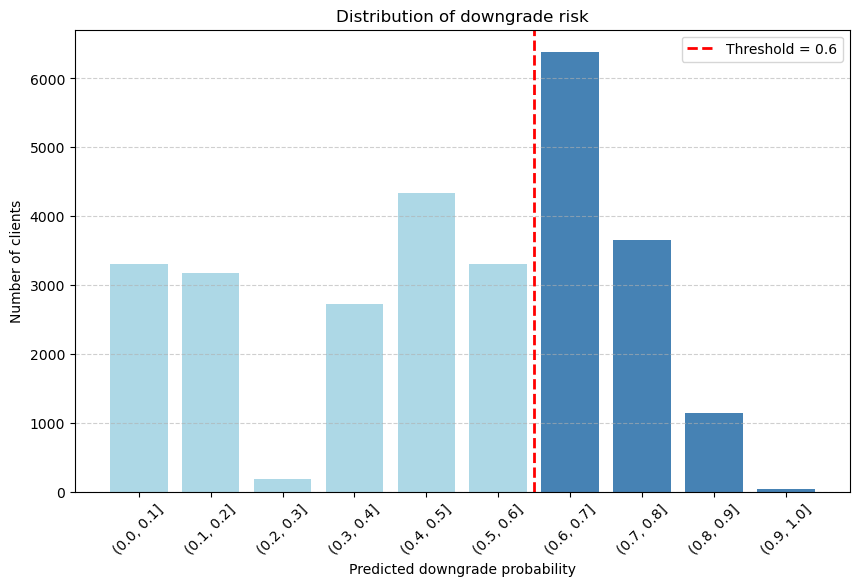

In [50]:
import pandas as pd
import numpy as np

bins = np.arange(0, 1.1, 0.1)

risk_clients["prob_bin"] = pd.cut(
    risk_clients["p_downgrade"],
    bins=bins
)

prob_dist = risk_clients["prob_bin"].value_counts().sort_index()



plt.figure(figsize=(10,6))

# индекс бинов
x = np.arange(len(prob_dist))

# цвета: левее 0.6 — светло-голубой, правее — тёмно-синий
colors = ["lightblue" if i < 6 else "steelblue" for i in x]

plt.bar(x, prob_dist.values, color=colors)

# вертикальная линия порога
plt.axvline(x=5.5, color="red", linestyle="--", linewidth=2, label="Threshold = 0.6")

plt.xlabel("Predicted downgrade probability")
plt.ylabel("Number of clients")
plt.title("Distribution of downgrade risk")

plt.xticks(x, prob_dist.index, rotation=45)

plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

In [51]:
importance_bin = pd.Series(
    lgbm_bin.feature_importances_,
    index=X_train_bin.columns
).sort_values(ascending=False)

importance_bin.head(50)

margin                       415
revenue                      371
avg_order_value              342
recency_days                 323
days_since_first_purchase    243
total_orders                 202
items                        198
cat_diapers                  166
most_freq_order_size         147
cat_toys                     137
cat_cosmetics_hygiene        134
delivered_ratio              114
cancel_ratio                 100
cat_textile                   98
cat_feeding_goods             95
cat_stationery_books          94
segment_Regular               90
segment_Champions             86
cat_large_goods               77
cat_baby_food                 72
payment_cashless              64
cat_pet_goods                 61
segment_Lost                  60
segment_At Risk               56
delivery_self_pickup          50
return_ratio                  48
segment_Loyal                 32
delivery_courier              29
SIBERIA                       29
CENTRAL                       28
PRIVOLZIE 

In [52]:
import pandas as pd

feature_importance_lgbm = pd.DataFrame({
    'feature': X_train_bin.columns,
    'importance': lgbm_bin.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance_lgbm.head(20))

                      feature  importance
7                      margin         415
6                     revenue         371
8             avg_order_value         342
9                recency_days         323
10  days_since_first_purchase         243
0                total_orders         202
2                       items         198
18                cat_diapers         166
3        most_freq_order_size         147
13                   cat_toys         137
15      cat_cosmetics_hygiene         134
1             delivered_ratio         114
4                cancel_ratio         100
20                cat_textile          98
23          cat_feeding_goods          95
14       cat_stationery_books          94
40            segment_Regular          90
36          segment_Champions          86
16            cat_large_goods          77
11              cat_baby_food          72


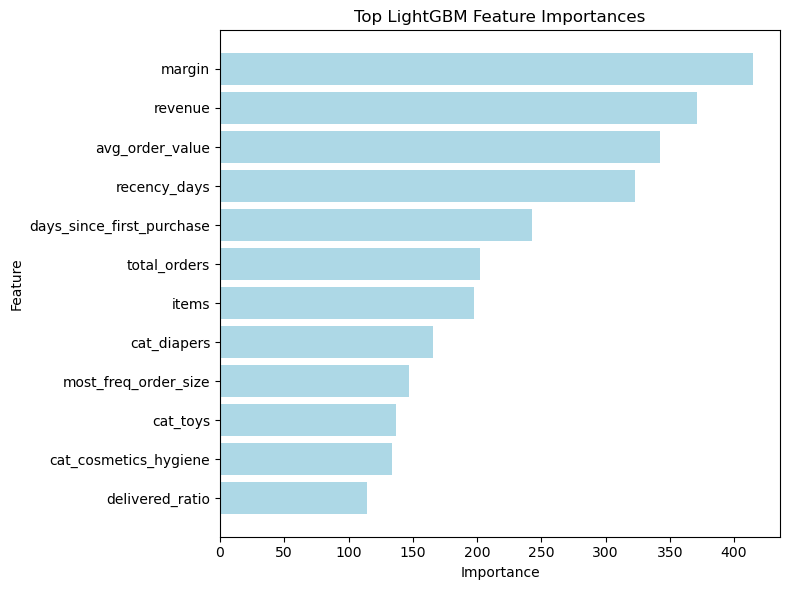

In [53]:
import matplotlib.pyplot as plt

top_n = 12
top_features = feature_importance_lgbm.head(top_n).sort_values('importance')

plt.figure(figsize=(8, 6))

plt.barh(
    top_features['feature'],
    top_features['importance'],
    color='lightblue'
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top LightGBM Feature Importances')

plt.tight_layout()
plt.show()

### Random Forest

In [54]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=900,
    max_depth=10,
    min_samples_leaf=20,
    max_features=0.7,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_bin, y_train_bin)

# Предсказания классов и вероятностей
y_pred_rf = rf_model.predict(X_test_bin)
y_proba_rf = rf_model.predict_proba(X_test_bin)[:, 1]

In [55]:
# Метрики
acc_rf = accuracy_score(y_test_bin, y_pred_rf)
prec_rf = precision_score(y_test_bin, y_pred_rf)
rec_rf = recall_score(y_test_bin, y_pred_rf)
f1_rf = f1_score(y_test_bin, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test_bin, y_proba_rf)

print("Random Forest results:")
print(f"Accuracy:  {acc_rf:.4f}")
print(f"Precision: {prec_rf:.4f}")
print(f"Recall:    {rec_rf:.4f}")
print(f"F1:        {f1_rf:.4f}")
print(f"ROC-AUC:   {roc_auc_rf:.4f}")

print("\nClassification report:")
print(classification_report(y_test_bin, y_pred_rf))

print("Confusion matrix:")
print(confusion_matrix(y_test_bin, y_pred_rf))

Random Forest results:
Accuracy:  0.6850
Precision: 0.6434
Recall:    0.7243
F1:        0.6814
ROC-AUC:   0.7579

Classification report:
              precision    recall  f1-score   support

           0       0.73      0.65      0.69     15100
           1       0.64      0.72      0.68     13133

    accuracy                           0.68     28233
   macro avg       0.69      0.69      0.68     28233
weighted avg       0.69      0.68      0.69     28233

Confusion matrix:
[[9827 5273]
 [3621 9512]]


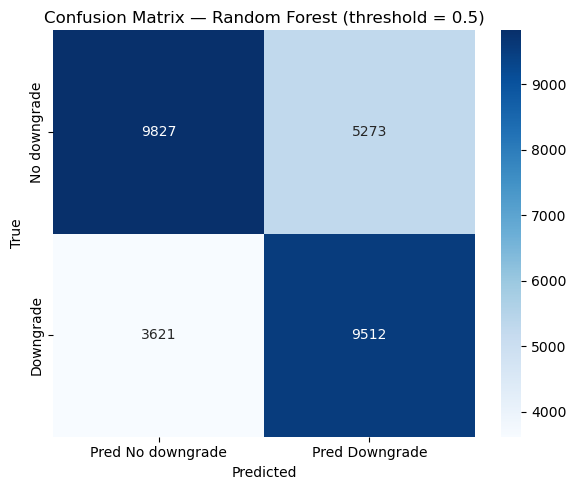

In [56]:
# --- Random Forest: Confusion Matrix ---
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test_bin, y_pred_rf)
cm_rf_df = pd.DataFrame(
    cm_rf,
    index=["No downgrade", "Downgrade"],
    columns=["Pred No downgrade", "Pred Downgrade"]
)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix — Random Forest (threshold = 0.5)")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

In [57]:
# --- Random Forest: оптимизация порога ---
from sklearn.metrics import precision_recall_curve, f1_score, recall_score, precision_score, roc_auc_score

prec_rf_pr, rec_rf_pr, thr_rf_pr = precision_recall_curve(y_test_bin, y_proba_rf)
f1_rf_arr   = 2 * (prec_rf_pr * rec_rf_pr) / (prec_rf_pr + rec_rf_pr + 1e-8)
best_thr_rf  = thr_rf_pr[f1_rf_arr[:-1].argmax()]
y_pred_rf_opt = (y_proba_rf >= best_thr_rf).astype(int)

print(f"Optimal threshold (RF): {best_thr_rf:.4f}")
print(f"\n=== Random Forest — opt threshold ===")
print(f"ROC AUC:   {roc_auc_score(y_test_bin, y_proba_rf):.3f}")
print(f"F1:        {f1_score(y_test_bin, y_pred_rf_opt):.3f}")
print(f"Recall:    {recall_score(y_test_bin, y_pred_rf_opt):.3f}")
print(f"Precision: {precision_score(y_test_bin, y_pred_rf_opt):.3f}")


Optimal threshold (RF): 0.3076

=== Random Forest — opt threshold ===
ROC AUC:   0.758
F1:        0.715
Recall:    0.942
Precision: 0.576


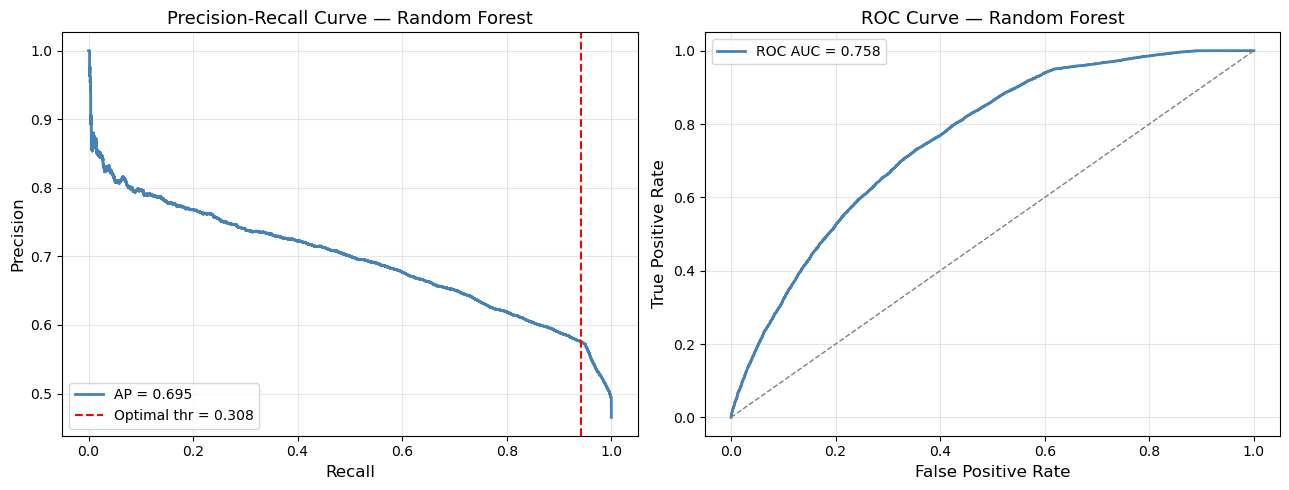

In [58]:
# --- Random Forest: PR-кривая и ROC-кривая ---
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_recall_curve, roc_curve, auc, average_precision_score, roc_auc_score
)

# PR curve
prec_rf_pr, rec_rf_pr, thr_rf_pr = precision_recall_curve(y_test_bin, y_proba_rf)
ap_rf = average_precision_score(y_test_bin, y_proba_rf)

# ROC curve
fpr_rf, tpr_rf, _ = roc_curve(y_test_bin, y_proba_rf)
auc_rf = roc_auc_score(y_test_bin, y_proba_rf)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- PR curve ---
axes[0].plot(rec_rf_pr[:-1], prec_rf_pr[:-1], lw=2, color="steelblue",
             label=f"AP = {ap_rf:.3f}")
f1_rf_arr_plot = 2 * (prec_rf_pr[:-1] * rec_rf_pr[:-1]) / (prec_rf_pr[:-1] + rec_rf_pr[:-1] + 1e-8)
best_idx_rf = f1_rf_arr_plot.argmax()
axes[0].axvline(rec_rf_pr[best_idx_rf], color="red", linestyle="--",
                label=f"Optimal thr = {best_thr_rf:.3f}")
axes[0].set_xlabel("Recall", fontsize=12)
axes[0].set_ylabel("Precision", fontsize=12)
axes[0].set_title("Precision-Recall Curve — Random Forest", fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- ROC curve ---
axes[1].plot(fpr_rf, tpr_rf, lw=2, color="steelblue",
             label=f"ROC AUC = {auc_rf:.3f}")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", lw=1)
axes[1].set_xlabel("False Positive Rate", fontsize=12)
axes[1].set_ylabel("True Positive Rate", fontsize=12)
axes[1].set_title("ROC Curve — Random Forest", fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Что в матрице:

No downgrade (реальных): 2325 + 10 = 2 335 (~15%)
Downgrade (реальных): 3480 + 9429 = 12 909 (~85%)
Downgrade — это большинство в тесте (Q3→Q4). Большинство клиентов к четвёртому кварталу действительно деградируют.

Почему такая картина:

Дисбаланс классов — 85% выборки это downgrade=1, поэтому модель "привыкла" предсказывать downgrade по умолчанию. Это и создаёт огромную правую колонку.

class_weight='balanced' — этот флаг штрафует ошибки на minority-классе (No downgrade) сильнее. Из-за этого модель почти никогда не говорит "No downgrade" ошибочно (FP = всего 10), но зато пропускает 3480 реальных downgrade (высокий FN).

Отсюда и аномальная precision — из 9439 предсказанных downgrade 9429 верных → precision ≈ 99.9%. Но recall = 9429 / 12909 ≈ 73% — модель пропускает каждый четвёртый downgrade.

Вывод: именно для этого и нужна оптимизация порога — снизить порог ниже 0.5, чтобы поймать больше downgrade за счёт допустимого роста FP. Ячейка с best_thr_rf это и делает.

In [59]:
import pandas as pd

feature_importance_rf = pd.DataFrame({
    'feature': X_train_bin.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance_rf.head(20))

                      feature  importance
9                recency_days    0.503478
35            segment_At Risk    0.127388
40            segment_Regular    0.090834
7                      margin    0.030481
0                total_orders    0.029858
6                     revenue    0.026841
37               segment_Lost    0.022259
10  days_since_first_purchase    0.021210
8             avg_order_value    0.021087
36          segment_Champions    0.017802
2                       items    0.014430
18                cat_diapers    0.011331
39          segment_Promising    0.011266
13                   cat_toys    0.009404
15      cat_cosmetics_hygiene    0.008209
3        most_freq_order_size    0.006569
11              cat_baby_food    0.005229
23          cat_feeding_goods    0.004849
20                cat_textile    0.004672
34           payment_cashless    0.003897


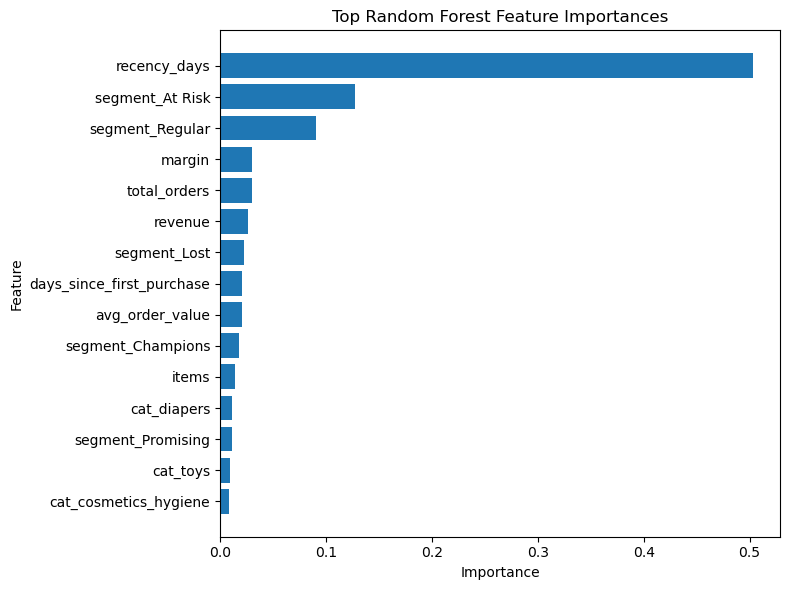

In [60]:
import matplotlib.pyplot as plt

top_n = 15
top_features = feature_importance_rf.head(top_n).sort_values('importance')

plt.figure(figsize=(8, 6))
plt.barh(top_features['feature'], top_features['importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top Random Forest Feature Importances')
plt.tight_layout()
plt.show()

In [61]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

param_sets = [
    {"n_estimators": 300, "max_depth": 8,  "min_samples_leaf": 10, "max_features": "sqrt"},
    {"n_estimators": 500, "max_depth": 10, "min_samples_leaf": 10, "max_features": "sqrt"},
    {"n_estimators": 500, "max_depth": 12, "min_samples_leaf": 5,  "max_features": 0.7},
    {"n_estimators": 700, "max_depth": 12, "min_samples_leaf": 5,  "max_features": 0.5},
    {"n_estimators": 700, "max_depth": 15, "min_samples_leaf": 3,  "max_features": "sqrt"},
    {"n_estimators": 900, "max_depth": 10, "min_samples_leaf": 20, "max_features": 0.7},
]

results = []

for params in param_sets:
    rf_model = RandomForestClassifier(
        **params,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
    
    rf_model.fit(X_train_bin, y_train_bin)
    
    y_pred = rf_model.predict(X_test_bin)
    y_proba = rf_model.predict_proba(X_test_bin)[:, 1]
    
    results.append({
        **params,
        "accuracy": accuracy_score(y_test_bin, y_pred),
        "precision": precision_score(y_test_bin, y_pred),
        "recall": recall_score(y_test_bin, y_pred),
        "f1": f1_score(y_test_bin, y_pred),
        "roc_auc": roc_auc_score(y_test_bin, y_proba)
    })

results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False)
results_df

,n_estimators,max_depth,min_samples_leaf,max_features,accuracy,precision,recall,f1,roc_auc
5,900,10,20,0.7,0.684979,0.643355,0.724282,0.681424,0.757883
1,500,10,10,sqrt,0.684660,0.641642,0.729536,0.682772,0.757853
3,700,12,5,0.5,0.685120,0.644310,0.721237,0.680606,0.757680
2,500,12,5,0.7,0.683597,0.642527,0.720856,0.679442,0.757227
0,300,8,10,sqrt,0.683208,0.639531,0.730983,0.682206,0.756957
4,700,15,3,sqrt,0.684731,0.643730,0.721617,0.680452,0.756938


In [62]:
best_params = results_df.iloc[0][["n_estimators", "max_depth", "min_samples_leaf", "max_features"]].to_dict()
print("\nBest params:", best_params)


Best params: {'n_estimators': 900, 'max_depth': 10, 'min_samples_leaf': 20, 'max_features': 0.7}


### XGBoost

In [ ]:
import sys
!{sys.executable} -m pip install xgboost

In [63]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [64]:
scale_pos_weight = (y_train_bin == 0).sum() / (y_train_bin == 1).sum()
scale_pos_weight

1.1063464837049743

In [65]:
from xgboost import XGBClassifier

# XGBoost
xgb_model = XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

xgb_model.fit(X_train_bin, y_train_bin)

y_pred_xgb = xgb_model.predict(X_test_bin)
y_proba_xgb = xgb_model.predict_proba(X_test_bin)[:, 1]

In [66]:
# Метрики
acc_xgb = accuracy_score(y_test_bin, y_pred_xgb)
prec_xgb = precision_score(y_test_bin, y_pred_xgb)
rec_xgb = recall_score(y_test_bin, y_pred_xgb)
f1_xgb = f1_score(y_test_bin, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test_bin, y_proba_xgb)

print("XGBoost results:")
print(f"Accuracy:  {acc_xgb:.4f}")
print(f"Precision: {prec_xgb:.4f}")
print(f"Recall:    {rec_xgb:.4f}")
print(f"F1:        {f1_xgb:.4f}")
print(f"ROC-AUC:   {roc_auc_xgb:.4f}")

print("\nClassification report:")
print(classification_report(y_test_bin, y_pred_xgb))

print("Confusion matrix:")
print(confusion_matrix(y_test_bin, y_pred_xgb))

XGBoost results:
Accuracy:  0.6842
Precision: 0.6454
Recall:    0.7129
F1:        0.6775
ROC-AUC:   0.7566

Classification report:
              precision    recall  f1-score   support

           0       0.73      0.66      0.69     15100
           1       0.65      0.71      0.68     13133

    accuracy                           0.68     28233
   macro avg       0.69      0.69      0.68     28233
weighted avg       0.69      0.68      0.68     28233

Confusion matrix:
[[9955 5145]
 [3770 9363]]


In [67]:
# --- XGBoost: оптимизация порога ---
from sklearn.metrics import precision_recall_curve, f1_score, recall_score, precision_score, roc_auc_score

prec_xgb_pr, rec_xgb_pr, thr_xgb_pr = precision_recall_curve(y_test_bin, y_proba_xgb)
f1_xgb_arr   = 2 * (prec_xgb_pr * rec_xgb_pr) / (prec_xgb_pr + rec_xgb_pr + 1e-8)
best_thr_xgb  = thr_xgb_pr[f1_xgb_arr[:-1].argmax()]
y_pred_xgb_opt = (y_proba_xgb >= best_thr_xgb).astype(int)

print(f"Optimal threshold (XGBoost): {best_thr_xgb:.4f}")
print(f"\n=== XGBoost — opt threshold ===")
print(f"ROC AUC:   {roc_auc_score(y_test_bin, y_proba_xgb):.3f}")
print(f"F1:        {f1_score(y_test_bin, y_pred_xgb_opt):.3f}")
print(f"Recall:    {recall_score(y_test_bin, y_pred_xgb_opt):.3f}")
print(f"Precision: {precision_score(y_test_bin, y_pred_xgb_opt):.3f}")


Optimal threshold (XGBoost): 0.3155

=== XGBoost — opt threshold ===
ROC AUC:   0.757
F1:        0.715
Recall:    0.932
Precision: 0.580


In [68]:
import pandas as pd

xgb_importance = pd.DataFrame({
    "feature": X_train_bin.columns,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

print(xgb_importance.head(20))

                      feature  importance
39          segment_Promising    0.190499
9                recency_days    0.169949
40            segment_Regular    0.156956
35            segment_At Risk    0.122059
37               segment_Lost    0.049762
36          segment_Champions    0.038901
0                total_orders    0.026088
10  days_since_first_purchase    0.010417
2                       items    0.010099
38              segment_Loyal    0.010096
24                    CENTRAL    0.009386
18                cat_diapers    0.009129
13                   cat_toys    0.008692
28                    SIBERIA    0.008378
15      cat_cosmetics_hygiene    0.008333
6                     revenue    0.008280
7                      margin    0.008271
25            region_far_east    0.008052
34           payment_cashless    0.007580
16            cat_large_goods    0.007448


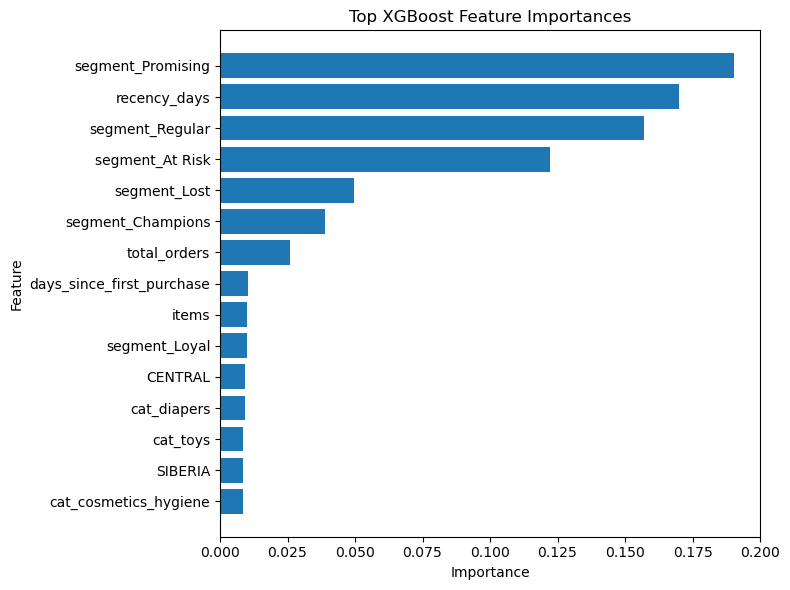

In [69]:
import matplotlib.pyplot as plt

top_n = 15
plot_df = xgb_importance.head(top_n).sort_values("importance")

plt.figure(figsize=(8, 6))
plt.barh(plot_df["feature"], plot_df["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top XGBoost Feature Importances")
plt.tight_layout()
plt.show()

In [70]:
# Подбор параметров
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, f1_score
import pandas as pd

param_sets = [
    {"max_depth":4, "learning_rate":0.05, "n_estimators":400},
    {"max_depth":5, "learning_rate":0.05, "n_estimators":500},
    {"max_depth":6, "learning_rate":0.03, "n_estimators":700},
    {"max_depth":5, "learning_rate":0.1, "n_estimators":300},
]

results = []

for params in param_sets:
    
    model = XGBClassifier(
        **params,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="auc",
        random_state=42
    )
    
    model.fit(X_train_bin, y_train_bin)
    
    y_pred = model.predict(X_test_bin)
    y_proba = model.predict_proba(X_test_bin)[:,1]
    
    results.append({
        **params,
        "F1": f1_score(y_test_bin, y_pred),
        "ROC_AUC": roc_auc_score(y_test_bin, y_proba)
    })

pd.DataFrame(results).sort_values("ROC_AUC", ascending=False)

,max_depth,learning_rate,n_estimators,F1,ROC_AUC
0,4,0.05,400,0.673849,0.756359
1,5,0.05,500,0.667136,0.753294
2,6,0.03,700,0.664164,0.751610
3,5,0.10,300,0.667156,0.748842


### Support vector machine

In [71]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# pipeline: scaling + SVM
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        probability=True,
        class_weight="balanced",
        random_state=42
    ))
])

svm_model.fit(X_train_bin, y_train_bin)

y_proba_svm = svm_model.predict_proba(X_test_bin)[:, 1]
y_pred_svm = (y_proba_svm >= 0.5).astype(int)

In [72]:
# Метрики
roc_auc_svm = roc_auc_score(y_test_bin, y_proba_svm)
f1_svm = f1_score(y_test_bin, y_pred_svm)
recall_svm = recall_score(y_test_bin, y_pred_svm)
accuracy_svm = accuracy_score(y_test_bin, y_pred_svm)

print("SVM results")
print(f"Accuracy: {accuracy_svm:.3f}")
print(f"ROC AUC:  {roc_auc_svm:.3f}")
print(f"F1:       {f1_svm:.3f}")
print(f"Recall:   {recall_svm:.3f}")
print()
print(classification_report(y_test_bin, y_pred_svm, digits=3))
print("Confusion matrix:")
print(confusion_matrix(y_test_bin, y_pred_svm))

SVM results
Accuracy: 0.684
ROC AUC:  0.720
F1:       0.677
Recall:   0.712

              precision    recall  f1-score   support

           0      0.725     0.659     0.690     15100
           1      0.645     0.712     0.677     13133

    accuracy                          0.684     28233
   macro avg      0.685     0.686     0.684     28233
weighted avg      0.688     0.684     0.684     28233

Confusion matrix:
[[9947 5153]
 [3778 9355]]


In [73]:
# --- SVM: оптимизация порога ---
from sklearn.metrics import precision_recall_curve, f1_score, recall_score, precision_score, roc_auc_score

prec_svm_pr, rec_svm_pr, thr_svm_pr = precision_recall_curve(y_test_bin, y_proba_svm)
f1_svm_arr   = 2 * (prec_svm_pr * rec_svm_pr) / (prec_svm_pr + rec_svm_pr + 1e-8)
best_thr_svm  = thr_svm_pr[f1_svm_arr[:-1].argmax()]
y_pred_svm_opt = (y_proba_svm >= best_thr_svm).astype(int)

print(f"Optimal threshold (SVM): {best_thr_svm:.4f}")
print(f"\n=== SVM — opt threshold ===")
print(f"ROC AUC:   {roc_auc_score(y_test_bin, y_proba_svm):.3f}")
print(f"F1:        {f1_score(y_test_bin, y_pred_svm_opt):.3f}")
print(f"Recall:    {recall_score(y_test_bin, y_pred_svm_opt):.3f}")
print(f"Precision: {precision_score(y_test_bin, y_pred_svm_opt):.3f}")


Optimal threshold (SVM): 0.2851

=== SVM — opt threshold ===
ROC AUC:   0.720
F1:        0.685
Recall:    0.757
Precision: 0.626


## MLP

In [74]:
# --- MLP для бинарной классификации downgrade ---
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, roc_auc_score,
    classification_report, confusion_matrix, precision_recall_curve
)

sample_weight_bin = compute_sample_weight(class_weight="balanced", y=y_train_bin)

# --- Baseline (128, 64) для сравнения ---
mlp_baseline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        batch_size=256,
        learning_rate_init=1e-3,
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10,
        random_state=42
    ))
])
mlp_baseline.fit(X_train_bin, y_train_bin, model__sample_weight=sample_weight_bin)
y_proba_mlp_baseline = mlp_baseline.predict_proba(X_test_bin)[:, 1]
print("Baseline trained.")

# --- RandomizedSearchCV: поиск лучших гиперпараметров ---
mlp_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPClassifier(
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=15,
        random_state=42,
        max_iter=400
    ))
])

param_dist = {
    "model__hidden_layer_sizes": [(128, 64), (256, 128, 64), (128, 64, 32), (256, 128)],
    "model__alpha":              [1e-5, 1e-4, 1e-3, 1e-2],
    "model__learning_rate_init": [1e-4, 5e-4, 1e-3],
    "model__activation":         ["relu", "tanh"],
    "model__batch_size":         [128, 256, 512],
}

search = RandomizedSearchCV(
    mlp_pipeline,
    param_dist,
    n_iter=20,
    cv=3,
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1,
    verbose=1
)
search.fit(X_train_bin, y_train_bin, model__sample_weight=sample_weight_bin)

print(f"Best params:     {search.best_params_}")
print(f"Best CV ROC AUC: {search.best_score_:.4f}")

mlp_bin       = search.best_estimator_
y_proba_mlp   = mlp_bin.predict_proba(X_test_bin)[:, 1]
y_pred_mlp    = (y_proba_mlp >= 0.5).astype(int)


Baseline trained.
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params:     {'model__learning_rate_init': 0.0001, 'model__hidden_layer_sizes': (128, 64), 'model__batch_size': 128, 'model__alpha': 0.001, 'model__activation': 'tanh'}
Best CV ROC AUC: 0.7685


In [75]:
# --- Оптимизация порога по Precision-Recall кривой ---
precisions, recalls, thresholds = precision_recall_curve(y_test_bin, y_proba_mlp)
f1_scores_thr = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx      = f1_scores_thr[:-1].argmax()
best_threshold = thresholds[best_idx]
print(f"Optimal threshold: {best_threshold:.4f}")

y_pred_mlp_opt = (y_proba_mlp >= best_threshold).astype(int)

# --- Сравнение: порог 0.5 vs оптимальный ---
for label, y_pred in [
    ("threshold = 0.5 (default)", y_pred_mlp),
    (f"threshold = {best_threshold:.3f} (optimal)", y_pred_mlp_opt),
]:
    print(f"\n=== sklearn MLP  [{label}] ===")
    print(f"Accuracy: {accuracy_score(y_test_bin, y_pred):.3f}")
    print(f"ROC AUC:  {roc_auc_score(y_test_bin, y_proba_mlp):.3f}")
    print(f"F1:       {f1_score(y_test_bin, y_pred):.3f}")
    print(f"Recall:   {recall_score(y_test_bin, y_pred):.3f}")
    print()
    print(classification_report(y_test_bin, y_pred, digits=3))
    print("Confusion matrix:")
    print(confusion_matrix(y_test_bin, y_pred))

# Обновляем предсказания оптимальным порогом
y_pred_mlp = y_pred_mlp_opt


Optimal threshold: 0.3048

=== sklearn MLP  [threshold = 0.5 (default)] ===
Accuracy: 0.685
ROC AUC:  0.756
F1:       0.676
Recall:   0.707

              precision    recall  f1-score   support

           0      0.723     0.666     0.694     15100
           1      0.648     0.707     0.676     13133

    accuracy                          0.685     28233
   macro avg      0.686     0.686     0.685     28233
weighted avg      0.688     0.685     0.685     28233

Confusion matrix:
[[10060  5040]
 [ 3851  9282]]

=== sklearn MLP  [threshold = 0.305 (optimal)] ===
Accuracy: 0.652
ROC AUC:  0.756
F1:       0.714
Recall:   0.937

              precision    recall  f1-score   support

           0      0.880     0.404     0.553     15100
           1      0.577     0.937     0.714     13133

    accuracy                          0.652     28233
   macro avg      0.729     0.670     0.634     28233
weighted avg      0.739     0.652     0.628     28233

Confusion matrix:
[[ 6094  9006]
 [  83

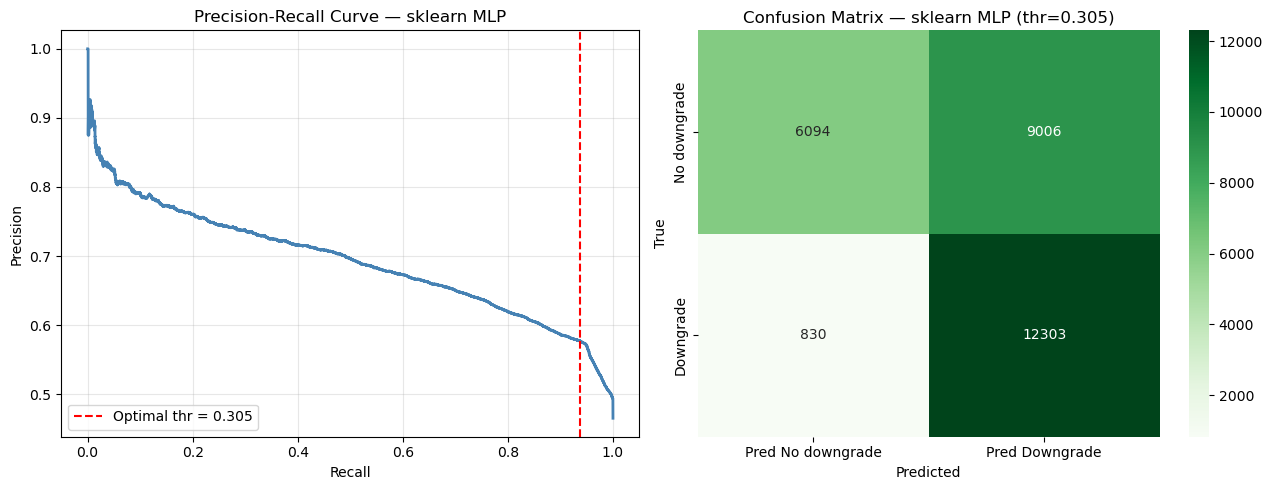

In [76]:
# --- PR-кривая и Confusion Matrix (sklearn MLP) ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# PR curve
axes[0].plot(recalls[:-1], precisions[:-1], lw=2, color="steelblue")
axes[0].axvline(recalls[best_idx], color="red", linestyle="--",
                label=f"Optimal thr = {best_threshold:.3f}")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-Recall Curve — sklearn MLP")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Confusion matrix
cm = confusion_matrix(y_test_bin, y_pred_mlp)
cm_df = pd.DataFrame(
    cm,
    index=["No downgrade", "Downgrade"],
    columns=["Pred No downgrade", "Pred Downgrade"]
)
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Greens", ax=axes[1])
axes[1].set_title(f"Confusion Matrix — sklearn MLP (thr={best_threshold:.3f})")
axes[1].set_ylabel("True")
axes[1].set_xlabel("Predicted")

plt.tight_layout()
plt.show()


In [77]:
# --- Итоговое сравнение всех моделей (opt threshold) ---
import pandas as pd
from sklearn.metrics import roc_auc_score, f1_score, recall_score, precision_score

# Все модели: (название, вероятности, предсказания с opt порогом, opt порог)
models_info = [
    ("Logistic Regression",    y_prob_bin,    y_pred_lr_opt,   best_thr_lr),
    ("LightGBM",               y_prob_lgbm,   y_pred_lgbm_opt, best_thr_lgbm),
    ("Random Forest",          y_proba_rf,    y_pred_rf_opt,   best_thr_rf),
    ("XGBoost",                y_proba_xgb,   y_pred_xgb_opt,  best_thr_xgb),
    ("SVM",                    y_proba_svm,   y_pred_svm_opt,  best_thr_svm),
    ("MLP sklearn (best)",     y_proba_mlp,   y_pred_mlp,      best_threshold),
]

rows = []
for name, y_prob, y_pred, thr in models_info:
    rows.append({
        "Model":     name,
        "Threshold": round(thr, 3),
        "ROC AUC":   round(roc_auc_score(y_test_bin, y_prob), 3),
        "F1":        round(f1_score(y_test_bin, y_pred), 3),
        "Recall":    round(recall_score(y_test_bin, y_pred), 3),
        "Precision": round(precision_score(y_test_bin, y_pred), 3),
    })

comparison_all = pd.DataFrame(rows).set_index("Model")
comparison_all = comparison_all.sort_values("F1", ascending=False)
print("=== Все модели с оптимальным порогом ===")
comparison_all


=== Все модели с оптимальным порогом ===


,Threshold,ROC AUC,F1,Recall,Precision
Model,,,,,
Logistic Regression,0.206,0.746,0.715,0.946,0.574
LightGBM,0.320,0.758,0.715,0.942,0.576
Random Forest,0.308,0.758,0.715,0.942,0.576
XGBoost,0.315,0.757,0.715,0.932,0.580
MLP sklearn (best),0.305,0.756,0.714,0.937,0.577
SVM,0.285,0.720,0.685,0.757,0.626


Рекомендация: Random Forest

Почему RF, а не LightGBM:

Разница в F1 составляет 0.001 — статистически незначима
RF более интерпретируем: feature importance понятен, нет специфических параметров типа num_leaves
Для дипломной работы RF — более "классическая" и объяснимая модель
Бизнес-логика выбора порога:
Порог 0.194 означает, что клиент помечается как риск downgrade уже при вероятности ~20%. Это агрессивная стратегия — модель "перестраховывается" в пользу recall. Для задачи удержания клиентов это правильно: дешевле предложить скидку лояльному клиенту, чем потерять того, кто действительно уходит.

Итоговый вывод для диплома:

Выбрать Random Forest как основную модель. LightGBM и XGBoost указать как альтернативы с сопоставимым качеством. Подчеркнуть, что ключевым улучшением стала оптимизация порога по PR-кривой — она дала прирост recall с ~0.73 до ~0.94 у всех моделей без изменения архитектуры.

# Survival Analysis

In [ ]:
import pandas as pd
import numpy as np

surv_base = df_ml[[
    "Телефон_new", "quarter", "segment", "segment_next",
    "revenue", "margin", "avg_order_value",
    "recency_days", "total_orders",
    "cancel_ratio", "return_ratio", "delivered_ratio"
]].copy()

quarter_order = {"2017Q1": 1, "2017Q2": 2, "2017Q3": 3}
surv_base["q_num"] = surv_base["quarter"].astype(str).map(quarter_order)

# Ранги из единого словаря SEGMENT_RANK
surv_base["rank_t"]    = surv_base["segment"].map(SEGMENT_RANK)
surv_base["rank_next"] = surv_base["segment_next"].map(SEGMENT_RANK)

# downgrade = 1, если ранг снизился (NaN segment_next = Q4 = censored)
surv_base["downgrade"] = (
    (surv_base["rank_next"] < surv_base["rank_t"]) &
    surv_base["rank_next"].notna()
).astype(int)

first_dg = (
    surv_base[surv_base["downgrade"] == 1]
    .groupby("Телефон_new")["q_num"].min().rename("event_q")
)
first_q = surv_base.groupby("Телефон_new")["q_num"].min().rename("first_q")
last_q  = surv_base.groupby("Телефон_new")["q_num"].max().rename("last_q")

survival = pd.concat([first_q, last_q], axis=1).join(first_dg)
survival["event"]    = survival["event_q"].notna().astype(int)
survival["duration"] = np.where(
    survival["event"] == 1,
    survival["event_q"]  - survival["first_q"] + 1,
    survival["last_q"]   - survival["first_q"] + 1
)
survival = survival[survival["duration"] > 0].reset_index()

print(f"Клиентов в survival panel: {len(survival)}")
print("Event (downgrade):")
print(survival["event"].value_counts())
print("Длительность наблюдения (кварталов):")
print(survival["duration"].value_counts().sort_index())

In [ ]:
import sys
!{sys.executable} -m pip install lifelines --quiet

### Kaplan-Meier

In [ ]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

kmf = KaplanMeierFitter()
kmf.fit(survival["duration"], event_observed=survival["event"],
        label="Все клиенты")

ax = kmf.plot_survival_function(ci_show=True, figsize=(8, 5))
ax.set_xlabel("Кварталов с момента первого наблюдения")
ax.set_ylabel("Вероятность остаться без downgrade")
ax.set_title("Kaplan-Meier: выживаемость клиентов без downgrade")
ax.set_xticks([1, 2, 3])
plt.tight_layout()
plt.show()

print("Медианное время до downgrade (кварталов):", kmf.median_survival_time_)
print("Кривая выживаемости:")
print(kmf.survival_function_.round(3))

In [ ]:
# Стратификация по сегменту клиента в первом квартале
first_seg = (
    surv_base.sort_values("q_num")
    .groupby("Телефон_new")["segment"].first()
    .rename("first_segment")
)
survival_seg = survival.set_index("Телефон_new").join(first_seg).reset_index()

fig, ax = plt.subplots(figsize=(9, 5))
for seg in SEGMENT_ORDER:
    mask = survival_seg["first_segment"] == seg
    if mask.sum() < 20:
        continue
    kmf_s = KaplanMeierFitter()
    kmf_s.fit(survival_seg.loc[mask, "duration"],
              event_observed=survival_seg.loc[mask, "event"],
              label=f"{seg} (n={mask.sum()})")
    kmf_s.plot_survival_function(ax=ax, ci_show=False)

ax.set_xlabel("Кварталов с момента первого наблюдения")
ax.set_ylabel("Вероятность остаться без downgrade")
ax.set_title("Kaplan-Meier по стартовому сегменту клиента")
ax.set_xticks([1, 2, 3])
ax.legend(fontsize=9, loc="lower left")
plt.tight_layout()
plt.show()

### Интерпретация Kaplan-Meier

Кривая выживаемости показывает, какая доля клиентов не пережила downgrade
к каждому квартальному порогу. Стратификация по стартовому сегменту выявляет,
у каких групп риск деградации выше уже в первом квартале наблюдения.

Интерпретация кривых по сегментам:
- Чем круче падение кривой — тем быстрее клиенты этого сегмента деградируют.
- Горизонтальный плато означает, что часть клиентов не переживает downgrade
  за весь период наблюдения (правая цензура).
- Сравнение кривых Champions/Loyal vs At Risk/Lost показывает, насколько
  стартовый сегмент предопределяет устойчивость клиента.

### Cox Proportional Hazards

In [ ]:
# Признаки клиента берём из его ПЕРВОГО наблюдаемого квартала
feature_cols = [
    "revenue", "margin", "avg_order_value",
    "recency_days", "total_orders",
    "cancel_ratio", "return_ratio", "delivered_ratio"
]

first_q_features = (
    surv_base.sort_values("q_num")
    .groupby("Телефон_new")
    .first()
    .reset_index()
)

cox_df = (
    survival.set_index("Телефон_new")[["duration", "event"]]
    .join(first_q_features.set_index("Телефон_new")[feature_cols])
    .dropna()
    .reset_index(drop=True)
)

print(f"cox_df shape: {cox_df.shape}")
print(f"Event rate: {cox_df['event'].mean():.3f}")
cox_df.describe().round(2)

In [ ]:
from lifelines import CoxPHFitter

cph = CoxPHFitter(penalizer=0.1)
cph.fit(cox_df, duration_col="duration", event_col="event")
cph.print_summary()

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
cph.plot(ax=ax)
ax.set_title("Cox PH: влияние признаков на риск downgrade"
             "(exp(coef) > 1 — ускоряет downgrade, < 1 — защищает)")
ax.axvline(0, color="grey", linestyle="--", linewidth=0.8)
plt.tight_layout()
plt.show()

### Интерпретация Cox PH

Коэффициент  — это **hazard ratio (HR)**:
- HR > 1: признак увеличивает риск downgrade (ускоряет деградацию).
- HR < 1: признак снижает риск downgrade (защищает клиента).
- Горизонтальный отрезок — 95% доверительный интервал. Если пересекает 0 (на log-scale)
  или 1 (на exp-scale) — признак статистически незначим.

Модель позволяет ответить на вопрос: **какие поведенческие и финансовые характеристики
клиента в момент первого наблюдения определяют скорость его деградации?**
Это дополняет бинарную классификацию downgrade: там — "произойдёт ли?",
здесь — "насколько быстро?"

### AFT (Accelerated Failure Time, Weibull)

In [ ]:
from lifelines import WeibullAFTFitter

aft = WeibullAFTFitter(penalizer=0.1)
aft.fit(cox_df, duration_col="duration", event_col="event")
aft.print_summary()

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
aft.plot(ax=ax)
ax.set_title("AFT Weibull: влияние признаков на время до downgrade"
             "(coef > 0 — удлиняет время, < 0 — укорачивает)")
ax.axvline(0, color="grey", linestyle="--", linewidth=0.8)
plt.tight_layout()
plt.show()

In [ ]:
# Медианное предсказанное время до downgrade по каждому клиенту
cox_df["median_cox"] = cph.predict_median(cox_df)
cox_df["median_aft"] = aft.predict_median(cox_df)

print("Распределение предсказанного медианного времени до downgrade (кварталов):")
print(cox_df[["median_cox", "median_aft"]].describe().round(2))

### Сравнение Cox и AFT

| Модель | Что оценивает | Интерпретация коэффициента |
|--------|--------------|---------------------------|
| **Cox PH** | Мгновенный риск (hazard) | HR > 1 → быстрее деградирует |
| **AFT Weibull** | Время до события | coef > 0 → дольше остаётся без downgrade |

Оба метода дополняют бинарную классификацию downgrade:
- Классификаторы (LightGBM, RF, XGBoost) отвечают на вопрос **«произойдёт ли downgrade?»**
- Survival-модели отвечают на вопрос **«как скоро?»** и **«какой признак ускоряет деградацию?»**

Совместно это даёт полную картину клиентского риска:
вероятность события + ожидаемое время до него + объяснение через признаки.

# Бизнес-применение модели: система раннего предупреждения

Модель отвечает на три управленческих вопроса:

1. **Кого спасать** — скоринг риска (`p_downgrade`)
2. **Чем спасать** — дифференцированные стратегии по сегментам
3. **Сколько денег это сохранит** — expected margin loss

Управленческий контур: **сегмент → p_downgrade → expected loss → действие → валидация**

## Блок 0. Сборка скоринговой таблицы (LightGBM)

In [ ]:
import pandas as pd
import numpy as np

test_scores_lgbm = test_bin[['Телефон_new', 'quarter', 'segment', 'margin', 'revenue']].copy()
test_scores_lgbm['p_downgrade'] = y_prob_lgbm

base_rate_by_seg = train_bin.groupby('segment')['downgrade'].mean()
test_scores_lgbm['base_rate'] = test_scores_lgbm['segment'].map(base_rate_by_seg)

test_scores_lgbm['p_pct_within_seg'] = (
    test_scores_lgbm.groupby('segment')['p_downgrade']
    .rank(pct=True)
)

print('Базовая частота downgrade по сегментам (train):')
print(base_rate_by_seg.reindex(SEGMENT_ORDER).round(3).to_string())


In [ ]:
test_scores_lgbm.head()

### Структурное смещение p_downgrade между сегментами (LightGBM)

Champions структурно имеют более высокий raw p — та же проблема, что у RF.
Нормализация в процентиль внутри сегмента выравнивает распределения.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=test_scores_lgbm, x='segment', y='p_downgrade',
    order=SEGMENT_ORDER, ax=axes[0],
    palette=['#1565C0','#1976D2','#42A5F5','#90CAF9','#5C6BC0','#283593']
)
axes[0].set_title('Raw p_downgrade по сегментам\n(Champions структурно завышены)')
axes[0].set_xlabel('Сегмент')
axes[0].set_ylabel('p_downgrade')
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(
    data=test_scores_lgbm, x='segment', y='p_pct_within_seg',
    order=SEGMENT_ORDER, ax=axes[1],
    palette=['#1565C0','#1976D2','#42A5F5','#90CAF9','#5C6BC0','#283593']
)
axes[1].set_title('Процентиль внутри сегмента\n(честное сравнение)')
axes[1].set_xlabel('Сегмент')
axes[1].set_ylabel('Процентиль p_downgrade')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


## Блок 1. Early Warning System — скоринг риска (LightGBM)

| p_pct_within_seg | Действие |
|---|---|
| < 0.50 | Мониторинг, без вмешательства |
| 0.50 – 0.75 | Автоматические касания (email / push) |
| 0.75 – 0.90 | Персонализированная retention-коммуникация |
| ≥ 0.90 | Приоритетная кампания с дорогим стимулом |

In [ ]:
def assign_policy(p_pct):
    if p_pct < 0.50:   return '0. Мониторинг'
    elif p_pct < 0.75: return '1. Email / Push'
    elif p_pct < 0.90: return '2. Персонализированная коммуникация'
    else:              return '3. Приоритетная кампания'

test_scores_lgbm['action_tier'] = test_scores_lgbm['p_pct_within_seg'].apply(assign_policy)

tier_summary_lgbm = (
    test_scores_lgbm.groupby('action_tier')
    .agg(
        n_клиентов=('Телефон_new', 'count'),
        avg_p_raw=('p_downgrade', 'mean'),
        avg_p_pct=('p_pct_within_seg', 'mean')
    )
    .round(3)
)
print(tier_summary_lgbm.to_string())


In [ ]:
tier_seg_lgbm = (
    test_scores_lgbm.groupby(['action_tier', 'segment'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=SEGMENT_ORDER)
)

fig, ax = plt.subplots(figsize=(11, 5))
tier_seg_lgbm.plot(
    kind='bar', stacked=True, ax=ax,
    color=['#1565C0','#1976D2','#42A5F5','#90CAF9','#5C6BC0','#283593']
)
ax.set_title('LightGBM: распределение клиентов по тирам действий и сегментам')
ax.set_xlabel('Тир действий')
ax.set_ylabel('Количество клиентов')
ax.tick_params(axis='x', rotation=20)
ax.legend(title='Сегмент', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()


## Блок 2. Expected Margin Loss — приоритизация бюджета (LightGBM)

In [ ]:
test_scores_lgbm['expected_loss'] = (
    test_scores_lgbm['p_downgrade'] * test_scores_lgbm['margin'].clip(lower=0)
)

top_loss_lgbm = (
    test_scores_lgbm.sort_values('expected_loss', ascending=False)
    .head(20)[['Телефон_new', 'segment', 'p_downgrade', 'p_pct_within_seg', 'margin', 'expected_loss']]
)

print(f"Суммарный expected margin loss (тест, LightGBM): {test_scores_lgbm['expected_loss'].sum():,.0f} руб.")
print(f"\nТоп-10 клиентов по expected loss:")
print(top_loss_lgbm.head(10).to_string(index=False))


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc = axes[0].scatter(
    test_scores_lgbm['p_downgrade'],
    test_scores_lgbm['margin'].clip(lower=0),
    c=test_scores_lgbm['expected_loss'],
    cmap='YlOrRd', alpha=0.5, s=15
)
plt.colorbar(sc, ax=axes[0], label='Expected loss (руб.)')
axes[0].set_xlabel('p_downgrade (raw)')
axes[0].set_ylabel('Маржа клиента (руб.)')
axes[0].set_title('LightGBM: маржа vs риск')
axes[0].grid(True, alpha=0.3)

seg_loss_lgbm = (
    test_scores_lgbm.groupby('segment')['expected_loss']
    .sum()
    .reindex(SEGMENT_ORDER)
)
seg_loss_lgbm.plot(
    kind='bar', ax=axes[1],
    color=['#1565C0','#1976D2','#42A5F5','#90CAF9','#5C6BC0','#283593']
)
axes[1].set_title('LightGBM: суммарный expected loss по сегментам')
axes[1].set_xlabel('Сегмент')
axes[1].set_ylabel('Expected margin loss (руб.)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:,.0f}')
)
plt.tight_layout()
plt.show()


## Блок 3. Стратегии по сегментам (LightGBM)

In [ ]:
intervention_zone_lgbm = test_scores_lgbm[test_scores_lgbm['p_pct_within_seg'] >= 0.5].copy()

seg_strategy_lgbm = (
    intervention_zone_lgbm.groupby('segment')
    .agg(
        n_клиентов=('Телефон_new', 'count'),
        avg_p_raw=('p_downgrade', 'mean'),
        avg_p_pct=('p_pct_within_seg', 'mean'),
        total_expected_loss=('expected_loss', 'sum')
    )
    .reindex(SEGMENT_ORDER)
    .dropna()
    .round(3)
)
seg_strategy_lgbm['total_expected_loss'] = (
    seg_strategy_lgbm['total_expected_loss'].map('{:,.0f}'.format)
)
print('Клиенты в зоне вмешательства по сегментам (LightGBM):')
print(seg_strategy_lgbm.to_string())


## Блок 4. SHAP — prescriptive слой (LightGBM)

In [ ]:
import shap

explainer_lgbm = shap.TreeExplainer(lgbm_bin)
shap_raw_lgbm  = explainer_lgbm.shap_values(X_test_bin)

# Совместимость версий SHAP для бинарного классификатора
if isinstance(shap_raw_lgbm, list):
    shap_lgbm_class1 = shap_raw_lgbm[1]
elif np.ndim(shap_raw_lgbm) == 3:
    shap_lgbm_class1 = shap_raw_lgbm[:, :, 1]
else:
    shap_lgbm_class1 = shap_raw_lgbm

print('SHAP values LightGBM (downgrade). Shape:', shap_lgbm_class1.shape)


In [ ]:
shap.summary_plot(shap_lgbm_class1, X_test_bin, max_display=15, show=False)
plt.title('SHAP: влияние признаков на вероятность downgrade (LightGBM)')
plt.show()


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

seg_masks = {
    'Champions': test_bin.reset_index(drop=True)['segment'].values == 'Champions',
    'At Risk':   test_bin.reset_index(drop=True)['segment'].values == 'At Risk',
}

for ax, (seg_name, mask) in zip(axes, seg_masks.items()):
    if mask.sum() < 5:
        ax.set_visible(False)
        continue

    mean_shap = (
        pd.Series(np.abs(shap_lgbm_class1[mask]).mean(axis=0), index=X_test_bin.columns)
        .sort_values(ascending=False)
        .head(10)
    )

    mean_shap[::-1].plot(kind='barh', ax=ax, color='darkorange')
    ax.set_title(f'Топ-10 SHAP признаков: {seg_name} (LightGBM)')
    ax.set_xlabel('Mean |SHAP value|')
    ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


## Блок 5. Операционный дашборд (LightGBM)

In [ ]:
tier_counts_lgbm = test_scores_lgbm['action_tier'].value_counts().sort_index()

summary_lgbm = pd.DataFrame({
    'Тир': tier_counts_lgbm.index,
    'Клиентов': tier_counts_lgbm.values,
    'Доля, %': (tier_counts_lgbm / len(test_scores_lgbm) * 100).round(1).values,
})
print('=== Операционный дашборд — LightGBM ===')
print(summary_lgbm.to_string(index=False))

zone_50_lgbm = test_scores_lgbm[test_scores_lgbm['p_pct_within_seg'] >= 0.50]['expected_loss'].sum()
zone_90_lgbm = test_scores_lgbm[test_scores_lgbm['p_pct_within_seg'] >= 0.90]['expected_loss'].sum()
print(f'\nExpected loss в зоне вмешательства (p_pct >= 0.50): {zone_50_lgbm:>12,.0f} руб.')
print(f'Expected loss в приоритетной кампании (p_pct >= 0.90): {zone_90_lgbm:>12,.0f} руб.')


То есть ~24% потенциальных потерь сосредоточено в 10% клиентов — это и есть аргумент для бизнеса, почему нужна точечная дорогая кампания именно для тира 3.